In [1]:
!pip install xgboost

In [2]:
!pip install shap # Para gerar os gráficos de explicabilidade do modelo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 11.8 MB/s eta 0:00:0031m12.5 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━━━━━━━ 2/3 [shap]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.2.0 which is incompatible.


# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)
**Dataset:** Adult Census Income  
**Tarefa de mineração:** Classificação
**Data da entrega:** 14/06/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Adult Census Income |
| Link público do dataset | https://www.kaggle.com/datasets/uciml/adult-census-income |
| Número de linhas | 32.561 |
| Número de colunas | 15 |
| Tarefa de mineração | Classificação |
| LLM usada na Trilha A | Gemini Pro |
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://gemini.google.com/share/68fcb4667de8 |
| Link da conversa — Trilha B | https://gemini.google.com/share/abcee9d7e641 |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Justiça e Mitigação de Viés | O dataset Adult Census Income possui um desbalanceamento histórico e estrutural severo, onde subgrupos de gênero e raça apresentam proporções de alta renda significativamente menores devido ao contexto social do Censo de 1994. A escolha desta diretriz é indispensável para auditar o comportamento do algoritmo e garantir que o classificador não converta essas desigualdades e correlações históricas em regras automatizadas de exclusão, operando de forma discriminatória direta ou indiretamente por meio de variáveis proxy (como ocupação ou relacionamento). | "Atue como um Auditor Independente de Viés Algorítmico. Analise as taxas de falsos negativos e o Impacto Díspar entre os subgrupos de gênero e raça para o modelo XGBoost treinado. Avalie se o algoritmo está perpetuando discriminação de forma direta ou por meio de variáveis proxy e proponha uma estratégia de pós-processamento (como ajuste de limiar de decisão) para equalizar as oportunidades." |
| Explicabilidade | O modelo selecionado (XGBoost) é um algoritmo de conjunto complexo baseado em árvores de decisão impulsionadas que, por sua natureza matemática não linear, opera originalmente como uma "caixa-preta" abstrata para humanos. A escolha desta diretriz justifica-se pela necessidade ética e técnica de abrir essa estrutura e mapear com precisão os fatores reais de negócio (como educação e ganho de capital) que fundamentam cada predição individual e global, garantindo transparência, auditabilidade e o direito à explicação. | "Atue como um Especialista em Inteligência Artificial Explicável (XAI). Com base nos valores SHAP globais e nos gráficos de dependência parcial gerados para o XGBoost, construa uma justificativa textual clara e acessível ao público geral explicando quais fatores profissionais (ex: nível educacional) ou de capital foram determinantes para a classificação de renda efetuada." |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [3]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais do TP3.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Dataset Adult Census Income usado no TP3.
# O caminho local funciona no repositório; a função de carregamento abaixo também
# aceita URL caso o notebook seja executado fora do ambiente do projeto.
DATA_PATH = Path("data/data_tp3/adult.csv")

# Tipo de tarefa do TP.
TASK_TYPE = "classificacao"

# Coluna-alvo da classificação binária.
TARGET_COLUMN = "income"

# Atributos sensíveis monitorados nas análises de viés.
SENSITIVE_COLUMNS = ["sex", "race"]

# No Adult Income, valores ausentes aparecem como "?" no CSV original.
MISSING_VALUE_MARKERS = ["?"]

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")
print(f"Coluna-alvo: {TARGET_COLUMN}")


Configuração carregada.
Tarefa definida: classificacao
Coluna-alvo: income


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio
- **Contexto:** Instituições governamentais, organizações do terceiro setor e departamentos de planejamento estratégico de empresas privadas frequentemente necessitam segmentar e compreender o perfil socioeconômico de populações para formular políticas públicas de redistribuição de renda, desenhar programas de assistência social ou direcionar ofertas de serviços essenciais. O mapeamento preciso da capacidade financeira individual, historicamente balizado por censos demográficos nacionais (como o Censo de 1994), serve como a fundação estrutural para estimar o bem-estar econômico e o potencial de desenvolvimento de uma sociedade.
- **Problema:** A coleta direta e exaustiva de dados de renda declarada é uma operação complexa, onerosa e sujeita a altas taxas de omissão ou subdeclaração por parte dos cidadãos. Diante disso, o problema central consiste em predizer de forma automatizada se a renda anual de um indivíduo supera ou não o limiar de USD 50.000 utilizando variáveis demográficas, educacionais e ocupacionais como preditores. O desafio analítico reside no fato de que os dados históricos herdam desigualdades estruturais de gênero e raça da época de sua coleta. Utilizar um classificador de alta capacidade (como o XGBoost) sem salvaguardas éticas criará um sistema que perpetua e automatiza essas discriminações do passado, mascarando preconceitos sob o pretexto de "otimização matemática".
- **Possíveis interessados:**
 - *Gestores de Políticas Públicas e Ministérios Sociais:* Interessados em identificar com precisão bolsas de pobreza ou regiões com maior concentração de indivíduos de baixa renda para alocação eficiente de recursos e subsídios, exigindo que os critérios de elegibilidade sejam transparentes e justos.
 - *Analistas de Crédito e Risco de Instituições Financeiras:* Que utilizam a estimativa de renda para avaliar a capacidade de endividamento e mitigar o risco de inadimplência na concessão de microcrédito.
 - *Comitês de Auditoria de IA e Ombudsman Éticos:* Profissionais responsáveis por garantir que as ferramentas preditivas da instituição estejam em conformidade com regulações de equidade, evitando processos jurídicos por discriminação algorítmica indireta.
- **Decisões apoiadas pela análise:**
 - *Concessão Justa de Benefícios ou Crédito:* Definição automatizada ou semiautomatizada de quais cidadãos preenchem os requisitos de faixa de renda para acessar incentivos fiscais, bolsas de estudo ou linhas de financiamento habitacional.
 - *Ajuste de Limiares de Decisão (Thresholds) por Equidade:* Decisão técnica e operacional de calibrar o ponto de corte do classificador XGBoost para equalizar as taxas de falsos negativos entre diferentes gêneros e raças, aceitando uma pequena variação na precisão global para garantir o cumprimento do princípio de Impacto Díspar Neutro.
 - *Intervenções de Capacitação Profissional:* Identificação de quais setores de ocupação ou níveis educacionais funcionam como os principais alavancadores de renda para guiar investimentos em escolas técnicas e programas de recolocação.
- **Limitações iniciais conhecidas:**
 - *Anacronismo dos Dados Históricos:* O dataset reflete a realidade socioeconômica dos Estados Unidos no ano de 1994. Portanto, as relações de valor e as distribuições de renda encontradas estão desatualizadas em relação à inflação e às dinâmicas do mercado de trabalho contemporâneo, limitando a validação prática a um cenário descritivo de simulação.
 - *Falta de Contexto Macroeconômico Atualizado:* A base carece de indicadores modernos importantes, como score de crédito, custo de vida regional, patrimônio acumulado ou arranjo familiar detalhado, restringindo o poder de explicação do modelo aos atributos contidos no censo.
 - *Desbalanceamento Crítico da Variável-Alvo:* A forte assimetria na distribuição da classe de renda (onde cerca de 76% da base ganha $\le$ 50K) impõe uma barreira severa ao treinamento do XGBoost, que pode inclinar suas fronteiras de decisão para ignorar a classe minoritária de alta renda, exigindo métricas de avaliação que penalizem o erro de forma assimétrica.

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O propósito central do dataset *Adult Census Income* é servir como uma base de referência para o desenvolvimento e avaliação de modelos de classificação supervisionada binária. O objetivo técnico consiste em predizer se a renda anual de um indivíduo excede ou não o patamar de 50 mil dólares (>50K ou <=50K) com base em um conjunto misto de atributos demográficos, educacionais e laborais. Sob a perspectiva de IA Responsável, o objetivo do dataset expande-se para atuar como um ambiente de testes (*benchmark*) para auditoria de algoritmos, identificação de preconceitos históricos ocultos e aplicação de técnicas de mitigação de impacto díspar e engenharia de explicabilidade pós-hoc.

### Origem dos dados

Os dados foram originalmente extraídos dos registros do escritório do Censo dos Estados Unidos (*United States Census Bureau*) relativos ao ano de 1994. A extração e a formatação inicial da base foram realizadas por Ronny Kohavi e Barry Becker, sendo posteriormente doadas ao Repositório de Aprendizado de Máquina da Universidade de Califórnia em Irvine (UCI Machine Learning Repository). O conjunto de dados tornou-se mundialmente difundido e está publicamente hospedado na plataforma Kaggle.

Link público: https://www.kaggle.com/datasets/uciml/adult-census-income

### Características do dataset

Abaixo estão detalhados os principais atributos que compõem a base de dados, mapeando sua natureza e papel na construção do classificador:

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
| --- | --- | --- | --- |
| `age` | Numérico (`int64`) | Idade do indivíduo em anos. | Altamente relevante por capturar o efeito do tempo de carreira e maturidade profissional no potencial de ganho. |
| `workclass` | Categórico (`object`) | Setor de ocupação trabalhista (ex: Private, Self-emp, Federal-gov, etc). | Crucial para entender a distribuição salarial entre a iniciativa privada, funcionalismo público e autônomos. |
| `education` | Categórico (`object`) | O mais alto nível de escolaridade formal alcançado pelo indivíduo. | Fornece o contexto nominal da formação, sendo uma variável de forte apelo descritivo de negócio. |
| `education-num` | Numérico (`int64`) | Nível educacional codificado estritamente pelo total de anos de estudo. | Altamente relevante por ser uma representação contínua da educação, ideal para o particionamento do XGBoost sem explodir a dimensionalidade. |
| `marital-status` | Categórico (`object`) | Estado civil do indivíduo (ex: Married-civ-spouse, Divorced, Never-married). | Relevante para o modelo pois, historicamente, o arranjo civil está correlacionado à estabilidade econômica e tributária familiar. |
| `occupation` | Categórico (`object`) | A ocupação profissional técnica exata do indivíduo (ex: Exec-managerial, Sales, Craft-repair). | Atributo de altíssimo poder preditivo que mapeia o teto de remuneração de cada setor de mercado. |
| `relationship` | Categórico (`object`) | Papel ou posição do indivíduo dentro do núcleo familiar (ex: Husband, Wife, Own-child). | Atua como uma forte variável preditiva, mas exige cuidado ético por carregar altos índices de colinearidade com gênero. |
| `race` | Categórico (`object`) | Etnia/raça autodeclarada do indivíduo (White, Black, Asian-Pac-Islander, etc). | **Atributo Sensível Crítico:** Deve ser auditado de forma estrita para evitar discriminação direta e avaliar o impacto díspar. |
| `sex` | Categórico (`object`) | Gênero biológico registrado (Male, Female). | **Atributo Sensível Crítico:** Utilizado diretamente na linha de frente para monitorar a equidade algorítmica e taxas de falsos negativos. |
| `capital-gain` | Numérico (`int64`) | Ganhos de capital financeiro obtidos por investimentos externos ao salário. | Variável monetária de cauda longa, de altíssima relevância para isolar indivíduos de renda muito elevada. |
| `capital-loss` | Numérico (`int64`) | Perdas de capital financeiro registradas no período. | Indica o envolvimento em investimentos de risco, servindo como proxy de movimentação patrimonial. |
| `hours-per-week` | Numérico (`int64`) | Quantidade de horas trabalhadas por semana. | Mede diretamente a intensidade da jornada laboral, correlacionando-se ao volume financeiro bruto recebido. |
| `native-country` | Categórico (`object`) | País de origem de nascimento do indivíduo. | Variável de alta cardinalidade utilizada para mapear o impacto geográfico e imigratório na renda. |
| `income` | Categórico (`object`) | **Variável-Alvo:** Rótulo indicando a faixa de renda anual (\texttt{<=50K} ou \texttt{>50K}). | É o alvo da classificação supervisionada. Determina o sucesso do aprendizado do XGBoost através de sua fronteira de decisão. |

*(Nota: O atributo original `fnlwgt` foi omitido desta tabela conceitual por se tratar de um peso amostral sociodemográfico populacional calculado pelo próprio censo da época, não possuindo correlação comportamental útil para o aprendizado do algoritmo.)*

### Relação com o problema de negócio

O dataset *Adult Census Income* é perfeitamente adequado para o problema de negócio escolhido devido à sua natureza multidimensional, que espelha os desafios analíticos complexos enfrentados por instituições ao tomarem decisões de concessão de crédito, incentivos ou benefícios.

Primeiramente, a base fornece o ecossistema ideal para testar a robustez do **XGBoost**, dada a presença massiva de atributos categóricos nominais cruzados com atributos numéricos de cauda longa e severamente assimétricos (como `capital-gain`). Em segundo lugar, o dataset resolve diretamente o problema de negócio de como gerenciar e mitigar vieses: ao disponibilizar variáveis demográficas explícitas (`sex` e `race`), ele permite quantificar de forma exata e matemática o desbalanceamento histórico nas decisões do modelo.

Por fim, a base atende à exigência de **Explicabilidade** corporativa, uma vez que o modelo final treinado precisará justificar, via valores SHAP, se a classificação de um indivíduo em uma faixa de renda menor decorreu de critérios técnicos legítimos de mercado (como escolaridade e horas trabalhadas) ou se foi contaminada de forma discriminatória indireta através das variáveis de controle.

## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
| --- | --- | --- |
| **Justiça e Mitigação de Viés** | O dataset herda as disparidades socioeconômicas estruturais dos EUA de 1994, registrando proporções historicamente menores de alta renda para mulheres e minorias éticas. Como o XGBoost possui alta capacidade de memorização e mapeamento não linear, ele tende a codificar essas desigualdades como regras preditivas rígidas. A diretriz é indispensável para forçar a auditoria das taxas de erro e impedir que o algoritmo discrimine de forma direta ou por variáveis *proxy*. | Espera-se que a LLM rejeite a acurácia global isolada e exija métricas de equidade (como Impacto Díspar ou Paridade Demográfica). Espera-se também que ela recomende pipelines de preparação focados em neutralidade, como a remoção ou o tratamento estatístico de atributos de alta colinearidade com gênero e raça (ex: `relationship`), e sugira pós-processamentos para calibração de limiares (*thresholds*). |
| **Explicabilidade** | O XGBoost funciona como um comitê sequencial de árvores complexas (*ensemble*), gerando uma estrutura matemática que opera como "caixa-preta" para tomadores de decisão humanos. Como classificar a renda de um cidadão impacta diretamente sua elegibilidade a benefícios ou crédito, é imperativo abrir o modelo para garantir transparência, auditabilidade e o direito à explicação do indivíduo. | Espera-se que a LLM proponha a integração obrigatória de métodos pós-hoc de explicabilidade agnósticos ao modelo, especificamente os valores **SHAP** (SHapley Additive exPlanations). Em vez de aceitar apenas métricas globais de erro, ela deve exigir a geração de gráficos de importância de atributos locais e globais para traduzir as decisões do XGBoost em justificativas de negócio inteligíveis. |

### Hipótese experimental

> Esperamos que, ao explicitar as diretrizes de *Justiça e Mitigação de Viés* e de *Explicabilidade* nas instruções da Trilha B (guiada), a LLM proponha um pipeline de classificação com **maior rigor ético no tratamento de dados, métricas de avaliação multidimensionais focadas em equidade e a incorporação mandatória de ferramentas de auditoria pós-hoc (SHAP)**, em comparação com a solução baseline (Trilha A). Na Trilha A, sem o direcionamento explícito dessas diretrizes, antecipa-se uma abordagem puramente tecnicista e focada na otimização matemática cega do XGBoost, priorizando a performance preditiva global (foco em métricas agregadas) em detrimento da transparência e da representatividade dos subgrupos protegidos.

### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

* **algoritmos sugeridos:** se haverá uma discussão sobre o uso de modelos intrinsecamente interpretáveis versus o XGBoost e como a complexidade do algoritmo escolhido é balanceada;
* **etapas de preparação dos dados:** se o pré-processamento inclui a engenharia de atributos neutros, tratamento de variáveis *proxy* e cuidados com o desbalanceamento sem introduzir novos vieses;
* **parâmetros recomendados:** se os hiperparâmetros sugeridos para o XGBoost incluem controles de regularização ($\mathbf{L1}$ e $\mathbf{L2}$) ou balanceamento de pesos de classe (`scale_pos_weight`) para lidar com a assimetria da base;
* **métricas propostas:** se a avaliação incorpora métricas de equidade e justiça algorítmica ou se permanece limitada a indicadores tradicionais de desempenho técnico;
* **justificativas técnicas:** o nível de profundidade conceitual ao defender as escolhas de engenharia de recursos e o ponto de corte (*threshold*) do classificador;
* **riscos apontados:** se a LLM detecta a reprodução automática de desigualdades históricas de gênero e raça contidas no censo de 1994;
* **limitações reconhecidas:** a capacidade de mapear a perda de interpretabilidade nativa do modelo e o custo computacional associado à explicabilidade pós-hoc;
* **aderência às diretrizes escolhidas:** o grau de engajamento do modelo de linguagem em atuar como um auditor crítico e transparente em vez de um mero otimizador de código.

## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 06/07/2026
**Link da conversa:** (https://gemini.google.com/share/8c72f57d7c9e)
**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset Adult Census Income.
A tarefa é Classificação Supervisionada Binária utilizando o algoritmo XGBoost.
Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,
origem dos dados, características gerais e relação com o problema.
```
#### Síntese da resposta da LLM

1. Contexto e Objetivo do Dataset
O dataset Adult Census Income (também conhecido como "Predict Census Income" ou simplesmente "UCI Adult Dataset") foi extraído do banco de dados do Censo de 1994 dos Estados Unidos por Ronny Kohavi e Barry Becker.
- Objetivo Primário: Determinar se a renda de uma pessoa excede o valor de US$ 50.000 por ano com base em dados demográficos e empregatícios.
- A Target: A variável alvo é binária (>50K ou ≤50K).O "Problema de Negócio"Embora a extração original visasse testar algoritmos de aprendizado de máquina, no contexto de negócios e políticas públicas, a capacidade de prever a faixa de renda de um indivíduo é crucial para:Instituições Financeiras: Avaliação de risco de crédito, concessão de empréstimos e oferta de produtos premium.Marketing Direcionado: Segmentação de clientes para produtos de alto valor.
- Governo e ONGs: Formulação de políticas socioeconômicas, alocação de recursos de assistência social e identificação de fatores que influenciam a desigualdade de renda.
2. Origem e Características Gerais dos Dados
Os dados são de natureza pública, extraídos do U.S. Census Bureau. 
O dataset possui 32.561 instâncias (no conjunto de treino padrão) e 14 atributos (recursos/features), além da variável preditora. Uma característica marcante é a mistura de tipos de dados:
- Variáveis Numéricas contínuas: Idade (age), ganho de capital (capital-gain), perda de capital (capital-loss) e horas trabalhadas por semana (hours-per-week).
- Variáveis Categóricas nominais e ordinais: Escolaridade (education, education-num), estado civil (marital-status), ocupação (occupation), relacionamento familiar (relationship), raça (race), sexo (sex) e país de origem (native-country).

Desafios Inerentes aos Dados (Data Understanding Preliminar)
- Desbalanceamento de Classes: Aproximadamente 24% das instâncias possuem renda >50K, enquanto 76% ganham ≤50K. Esse desbalanceamento deve ser levado em conta na hora de avaliar o XGBoost (usando métricas como F1-Score ou AUC-ROC em vez de apenas Acurácia).
- Dados Ausentes: Existem valores omitidos (frequentemente representados por ?) em variáveis como workclass, occupation e native-country.

3. Relação com o Problema: 
Por que usar XGBoost? A modelagem preditiva neste dataset busca mapear como características estruturais e comportamentais impactam o poder aquisitivo. O algoritmo XGBoost (Extreme Gradient Boosting) se justifica por várias razões de negócio e técnicas:
- Relações Não-Lineares e Interações: Fatores como "Idade" e "Horas Trabalhadas" não aumentam a renda de forma puramente linear. O pico de ganho geralmente ocorre na meia-idade. Modelos baseados em árvores de decisão capturam essas nuances perfeitamente.
- Tratamento de Variáveis Categóricas: O XGBoost lida muito bem com o grande volume de features categóricas deste dataset (após a devida codificação como Target Encoding ou One-Hot Encoding).
- Regularização: Como o dataset possui atributos que podem gerar forte correlação ou sobreajuste (ex: education e education-num medem conceitos muito similares), os parâmetros de regularização L1 ($\lambda$) e L2 ($\alpha$) do XGBoost ajudam a manter o modelo generalizável.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro 
**Data de acesso:** 07/06/2026 
**Link da conversa:** https://gemini.google.com/share/2f4b53d8f401
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset Adult Census Income.
A tarefa é Classificação Supervisionada Binária utilizando o algoritmo XGBoost para prever se a renda de um indivíduo excede 50K anuais.
Ajude-me a formular o Business Understanding.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. Justiça e Mitigação de Viés: O censo de 1994 herda desigualdades históricas de gênero (sex) e raça (race). O modelo não pode perpetuar ou automatizar essas discriminações como regras preditivas rígidas.
2. Explicabilidade: O XGBoost é um modelo ensemble de alta complexidade matemática (caixa-preta). Precisamos auditar e explicar o peso de variáveis legítimas (educação, capital-gain) versus atributos sensíveis de forma transparente.

Além da descrição do problema, indique riscos, limitações e critérios éticos que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

1. Business Understanding (Entendimento do Negócio)

1.1. Contexto e Objetivo
O objetivo deste projeto é aplicar o algoritmo **XGBoost** para uma tarefa de Classificação Binária utilizando o dataset *Adult Census Income* (1994). A meta é prever se a renda anual de um indivíduo excede US$ 50K com base em atributos censitários. Contextos de negócio para este tipo de modelo incluem *credit scoring*, marketing direcionado e alocação de recursos públicos.

1.2. Diretrizes de IA Responsável
Como sistemas preditivos baseados em dados históricos tendem a automatizar desigualdades do passado, este projeto adota diretrizes estritas:

* **Justiça e Mitigação de Viés:** O censo de 1994 contém vieses históricos profundos em relação a gênero (`sex`) e raça (`race`). O objetivo ético é evitar que o modelo utilize essas desigualdades estruturais como regras preditivas, buscando métricas de equidade (como *Equalized Odds*).
* **Explicabilidade (Auditoria do XGBoost):** Sendo o XGBoost um modelo de alta complexidade (*caixa-preta*), a auditoria de suas decisões é obrigatória. Utilizaremos ferramentas como **SHAP values** para garantir de forma transparente que variáveis legítimas (como `education` e `capital-gain`) conduzam a predição, monitorando o impacto dos atributos sensíveis.

1.3. Riscos e Limitações
* **Variáveis Proxy:** Risco do algoritmo recriar vieses através de variáveis correlacionadas aos atributos sensíveis (ex: `relationship` ou `occupation` agindo como *proxies* para gênero).
* **Obsolescência dos Dados:** Dados de 1994 não refletem a economia atual. O modelo serve estritamente para propósitos de pesquisa e estudo algorítmico, não devendo ser implantado em produção sem dados contemporâneos.
* **Critério de Sucesso:** O sucesso do projeto será medido não apenas pela maximização do F1-Score ou ROC-AUC, mas pela distribuição equitativa dos erros entre diferentes grupos demográficos.

## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Define corretamente a tarefa como classificação binária para prever `income` (`<=50K` ou `>50K`) e relaciona o problema a crédito, marketing e políticas públicas. | Mantém a mesma definição técnica, mas explicita que o uso prático exige cautela por envolver renda, elegibilidade e possível impacto sobre grupos sociais. | A Trilha B não muda o problema, mas torna mais claro que a predição de renda é uma decisão sensível e não apenas um exercício de desempenho preditivo. |
| Relação com o dataset | Reconhece a origem no Censo dos EUA de 1994, a mistura de atributos numéricos e categóricos, o desbalanceamento da classe `>50K` e os valores `?` em `workclass`, `occupation` e `native.country`. | Além desses pontos, conecta `sex`, `race`, `relationship` e `occupation` a riscos de desigualdade histórica, variáveis proxy e interpretação social das predições. | A resposta guiada usa melhor o contexto do Adult Income porque interpreta as colunas não só como preditores, mas também como evidências de possíveis vieses. |
| Consideração das diretrizes | Recomenda métricas tradicionais como F1-score e ROC-AUC e justifica o XGBoost por desempenho, regularização e capacidade de capturar relações não lineares. | Incorpora explicitamente Justiça e Mitigação de Viés e Explicabilidade, sugerindo auditoria por subgrupos, métricas de equidade e uso de SHAP para interpretar o XGBoost. | A Trilha B apresenta aderência concreta às diretrizes escolhidas; a baseline trata responsabilidade apenas de forma indireta, quando menciona desbalanceamento. |
| Identificação de riscos | Aponta riscos técnicos gerais: classe desbalanceada, dados ausentes e correlação entre `education` e `education.num`. | Aponta riscos éticos e metodológicos: reprodução de desigualdades de gênero e raça, uso de variáveis proxy, obsolescência dos dados de 1994 e uso indevido em produção. | A diferença é substancial: a baseline identifica problemas de modelagem; a guiada identifica também riscos de impacto social e limites de aplicação. |
| Qualidade da justificativa | A justificativa para o XGBoost é tecnicamente plausível, principalmente por lidar com interações e não linearidades. | A justificativa é mais completa porque condiciona o uso do XGBoost a auditoria, explicabilidade e avaliação multidimensional dos erros. | A Trilha B evita a ideia de que maior desempenho global basta para validar a solução. |
| Erros ou omissões | Não discute suficientemente `sex` e `race` como atributos sensíveis, nem o risco de `relationship` e `occupation` atuarem como proxies. Também não separa claramente sucesso preditivo de sucesso ético. | Ainda depende de validações que precisam ser implementadas pelo grupo, como medir taxas de erro por subgrupo e verificar se SHAP será viável computacionalmente. | A Trilha B reduz omissões relevantes, mas não substitui a verificação empírica. O grupo precisa confirmar as recomendações com código e métricas. |

### Síntese crítica

A Trilha B deve ser considerada melhor para o Business Understanding porque produziu mudanças concretas na formulação do problema. Enquanto a Trilha A oferece uma leitura correta, mas predominantemente técnica, a Trilha B reposiciona o Adult Census Income como um dataset historicamente sensível: a variável-alvo `income` não é neutra, e atributos como `sex`, `race`, `relationship` e `occupation` podem carregar desigualdades sociais do Censo de 1994.

A principal melhoria está na definição dos critérios de sucesso. Na baseline, o sucesso tende a ser medido por métricas agregadas de classificação, como F1-score, ROC-AUC e matriz de confusão. Na trilha guiada, essas métricas continuam relevantes, mas deixam de ser suficientes: passa a ser necessário avaliar distribuição de erros entre subgrupos, impacto díspar, influência de atributos sensíveis e explicações globais e locais por SHAP. Isso torna a solução mais alinhada às diretrizes de Justiça e Mitigação de Viés e Explicabilidade.

A análise crítica do grupo é aceitar a Trilha B como referência conceitual, mas sem adotar suas sugestões de forma automática. A recomendação de auditar vieses é pertinente, porém só terá validade se for operacionalizada nas próximas seções com cruzamentos entre `income`, `sex` e `race`, tratamento explícito dos valores `?`, separação correta entre treino e teste e documentação dos trade-offs entre desempenho, explicabilidade e equidade. Assim, a contribuição da LLM guiada foi mais robusta, mas a responsabilidade pela validação técnica permanece do grupo.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [4]:
# Carregamento do dataset Adult Census Income
# O arquivo local usa valores ausentes codificados como "?".

from pathlib import Path
import pandas as pd


def resolver_caminho_dataset(caminho):
    """Resolve o caminho do dataset tanto a partir da raiz do repo quanto da pasta do notebook."""
    caminho = Path(caminho) if not str(caminho).startswith(("http://", "https://")) else caminho

    if isinstance(caminho, str):
        return caminho

    candidatos = [
        caminho,
        Path.cwd() / caminho,
        Path.cwd().parent.parent / caminho,
    ]

    for candidato in candidatos:
        if candidato.exists():
            return candidato

    raise FileNotFoundError(f"Arquivo local não encontrado. Caminhos testados: {candidatos}")


def carregar_dataset(caminho, missing_values=None) -> pd.DataFrame:
    """Carrega o dataset Adult Income a partir de um caminho local ou URL CSV."""
    missing_values = missing_values or []

    if str(caminho).startswith(("http://", "https://")):
        return pd.read_csv(caminho, na_values=missing_values)

    caminho_resolvido = resolver_caminho_dataset(caminho)

    if Path(caminho_resolvido).suffix.lower() != ".csv":
        raise ValueError("Formato não tratado neste notebook. Esperado um arquivo .csv.")

    return pd.read_csv(caminho_resolvido, na_values=missing_values)


df = carregar_dataset(DATA_PATH, missing_values=MISSING_VALUE_MARKERS)

print("Dataset carregado com sucesso!")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
print(f"Coluna-alvo: {TARGET_COLUMN}")
display(df.head())


Dataset carregado com sucesso!
Número de linhas: 32561
Número de colunas: 15
Coluna-alvo: income


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 32561
- Colunas: 15
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [6]:
# Exploração inicial do Adult Census Income
# Esta célula resume tipos, nulos reais e papel analítico das colunas.


def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    resumo["papel"] = "feature"
    resumo.loc[TARGET_COLUMN, "papel"] = "alvo"
    resumo.loc[[c for c in SENSITIVE_COLUMNS if c in resumo.index], "papel"] = "atributo sensível"

    return resumo.sort_values(by=["papel", "perc_nulos", "n_unicos"], ascending=[True, False, False])


resumo = resumo_inicial(df)
display(resumo)

print("Distribuição da variável-alvo:")
display(
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="frequencia")
    .assign(percentual=lambda tabela: (tabela["frequencia"] / len(df) * 100).round(2))
)

for coluna in SENSITIVE_COLUMNS:
    if coluna in df.columns:
        print(f"Distribuição de {TARGET_COLUMN} por {coluna}:")
        display(pd.crosstab(df[coluna], df[TARGET_COLUMN], normalize="index").round(3))


,tipo,n_nulos,perc_nulos,n_unicos,papel
income,object,0,0.00,2,alvo
race,object,0,0.00,5,atributo sensível
sex,object,0,0.00,2,atributo sensível
occupation,object,1843,5.66,14,feature
workclass,object,1836,5.64,8,feature
native.country,object,583,1.79,41,feature
fnlwgt,int64,0,0.00,21648,feature
capital.gain,int64,0,0.00,119,feature
hours.per.week,int64,0,0.00,94,feature
capital.loss,int64,0,0.00,92,feature


Distribuição da variável-alvo:


,income,frequencia,percentual
0,<=50K,24720,75.92
1,>50K,7841,24.08


Distribuição de income por sex:


income,<=50K,>50K
sex,,
Female,0.891,0.109
Male,0.694,0.306


Distribuição de income por race:


income,<=50K,>50K
race,,
Amer-Indian-Eskimo,0.884,0.116
Asian-Pac-Islander,0.734,0.266
Black,0.876,0.124
Other,0.908,0.092
White,0.744,0.256


In [7]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Colunas não numéricas: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
workclass,30725,8,Private,22696
education,32561,16,HS-grad,10501
marital.status,32561,7,Married-civ-spouse,14976
occupation,30718,14,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native.country,31978,41,United-States,29170
income,32561,2,<=50K,24720


## 2.1 Exploração inicial — interpretação

O dataset carregado possui **32.561 linhas e 15 colunas**, coerente com a versão clássica do *Adult Census Income*. A tarefa é de **classificação binária**, tendo `income` como variável-alvo, com as classes `<=50K` e `>50K`. O conjunto combina atributos numéricos (`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`) e atributos categóricos (`workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country` e `income`).

A exploração inicial mostra três pontos de qualidade importantes. Primeiro, os valores ausentes não aparecem originalmente como `NaN`, mas como o marcador textual `?`; por isso o carregamento foi ajustado para convertê-los corretamente. As colunas afetadas são `workclass`, `occupation` e `native.country`. Segundo, há forte desbalanceamento da variável-alvo: a classe `<=50K` representa cerca de **75,9%** dos registros, enquanto `>50K` representa cerca de **24,1%**. Terceiro, `fnlwgt` possui cardinalidade muito alta e não é identificador individual; trata-se de um peso amostral do censo, devendo ser tratado com cautela na modelagem e na explicação.

As variáveis `sex` e `race` são atributos sensíveis diretos. Além delas, `relationship`, `occupation`, `marital.status`, `education` e `native.country` podem funcionar como variáveis proxy, pois estão associadas a estruturas sociais, familiares, educacionais e ocupacionais que também refletem desigualdades históricas. A presença desses atributos não implica remoção automática, mas exige auditoria explícita de desempenho e erro por subgrupo.

Também há variáveis de grande relevância preditiva e interpretativa. `education.num`, `education`, `occupation`, `capital.gain`, `capital.loss` e `hours.per.week` tendem a carregar sinal forte para a predição de renda. Contudo, `capital.gain` e `capital.loss` apresentam distribuição muito concentrada em zero e cauda longa, o que pode fazer o modelo atribuir grande peso a poucos registros extremos. Essa característica deve ser considerada na preparação e na etapa de explicabilidade.

### Relação com as diretrizes escolhidas

Para **Justiça e Mitigação de Viés**, a exploração inicial confirma que o dataset exige análise por subgrupos. A proporção de registros `>50K` é maior entre homens do que entre mulheres e também varia entre grupos raciais, o que indica risco de o classificador aprender desigualdades históricas como padrão decisório. Portanto, a avaliação não deve se limitar à acurácia global: será necessário comparar métricas como recall, falsos negativos e precisão entre `sex` e `race`.

Para **Explicabilidade**, o dataset é favorável porque a maioria das colunas tem significado semântico claro. Porém, a explicação precisa distinguir atributos legítimos para interpretação socioeconômica, como escolaridade e horas trabalhadas, de atributos sensíveis ou proxies. Assim, a preparação deve preservar nomes de variáveis rastreáveis após codificação categórica e documentar qualquer remoção, agrupamento ou transformação aplicada antes do XGBoost.


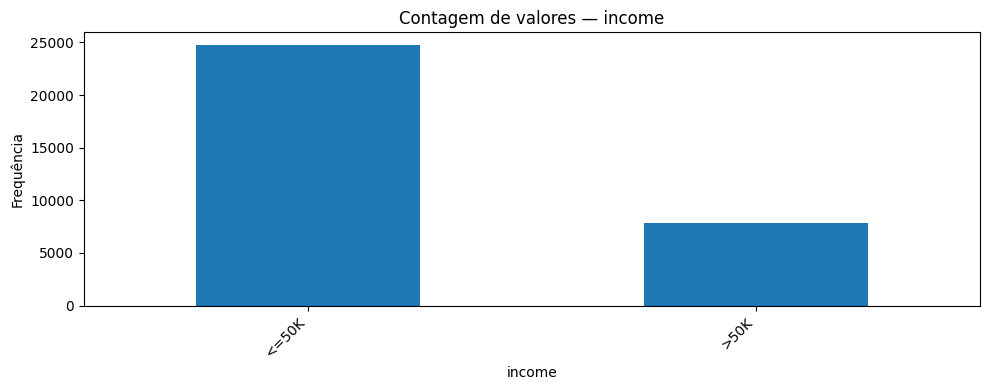

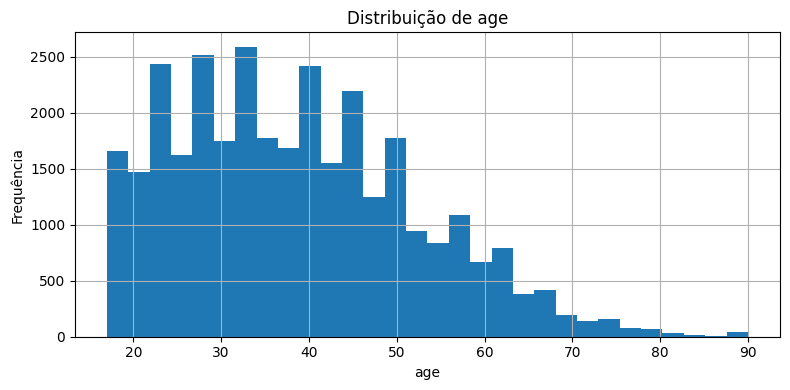

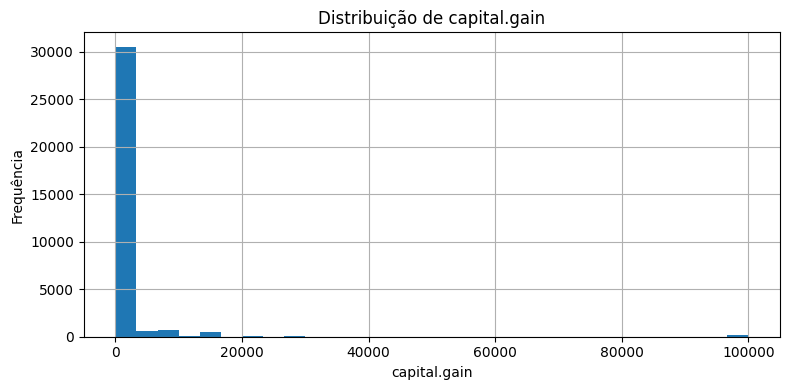

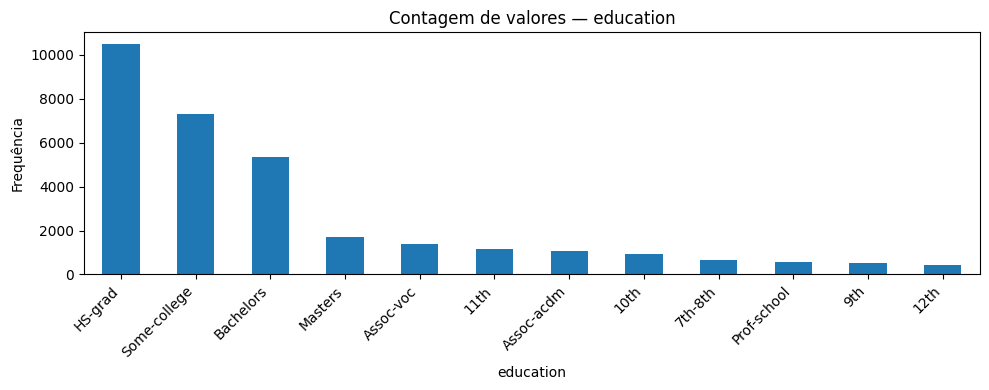

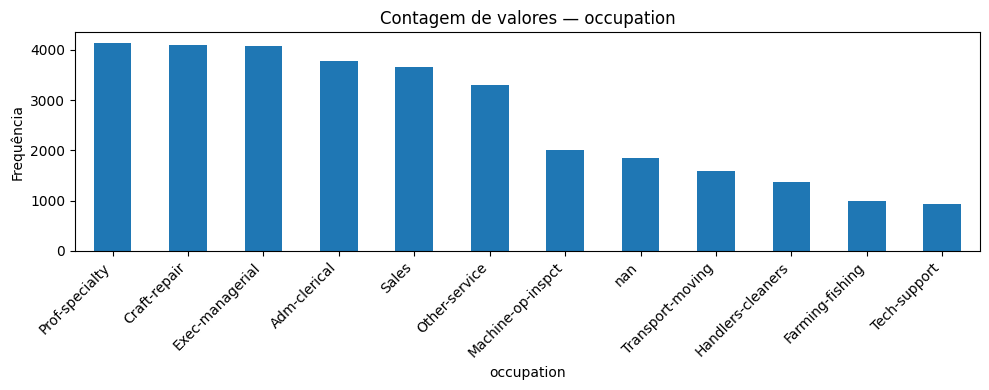

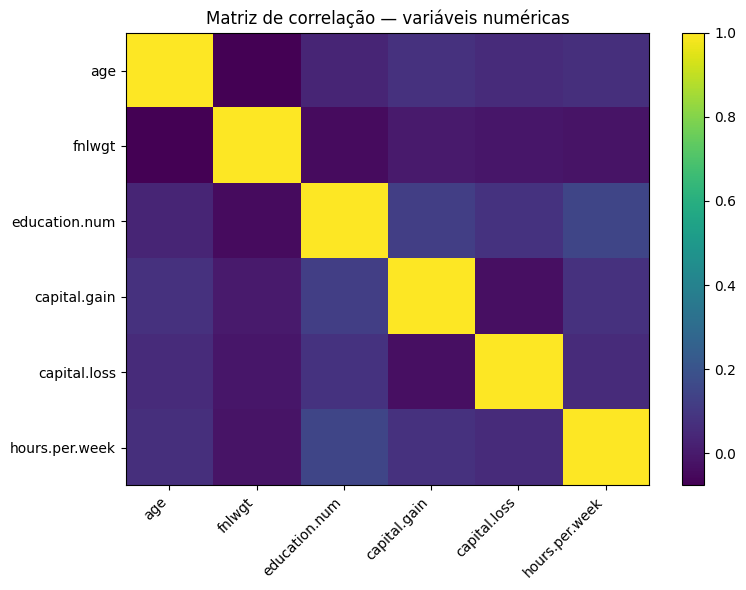

In [8]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Gráficos usados na interpretação da Seção 2.2.
plot_contagem_categorica(df, TARGET_COLUMN)
plot_distribuicao_numerica(df, "age")
plot_distribuicao_numerica(df, "capital.gain")
plot_contagem_categorica(df, "education", top_n=12)
plot_contagem_categorica(df, "occupation", top_n=12)
plot_matriz_correlacao(df)


## 2.2 Análise visual — interpretação

A análise visual confirma que o dataset possui uma estrutura adequada para uma tarefa de classificação binária, mas com desafios importantes de modelagem e de IA responsável.

O primeiro gráfico, referente à variável-alvo `income`, evidencia um desbalanceamento relevante: a classe `<=50K` representa aproximadamente **75,92%** dos registros, enquanto `>50K` representa apenas **24,08%**. Portanto, a acurácia isolada não deve ser usada como principal métrica, pois um classificador enviesado para a classe majoritária poderia parecer bom sem identificar bem os indivíduos de maior renda. Para a modelagem, isso justifica o uso de divisão estratificada e métricas como `precision`, `recall`, `f1-score`, matriz de confusão e, quando possível, AUC.

A distribuição de `age` é assimétrica à direita. A maior concentração está em adultos em idade economicamente ativa, principalmente entre o fim dos 20 e os 50 anos, com poucos registros em idades muito altas. Esses valores extremos de idade não devem ser removidos automaticamente, pois são plausíveis no contexto censitário e podem representar padrões reais de permanência no mercado de trabalho.

Os gráficos de `capital.gain` e, por analogia, `capital.loss` indicam forte concentração em zero e poucos valores positivos muito altos. Embora o critério IQR marque muitos desses casos como outliers, eles não parecem erros de digitação: no Adult Census Income, ganhos e perdas de capital são eventos raros, mas potencialmente muito informativos para prever renda. Assim, a decisão mais adequada é manter esses atributos e permitir que modelos baseados em árvores capturem seus efeitos, ou avaliar transformações apenas na Fase 3 se houver instabilidade.

Nas variáveis categóricas, `education` mostra predominância de `HS-grad`, `Some-college` e `Bachelors`, enquanto `occupation` concentra muitas observações em categorias como `Prof-specialty`, `Craft-repair`, `Exec-managerial`, `Adm-clerical` e `Sales`. A presença de valores ausentes em `occupation` e `workclass` também aparece de forma perceptível nas contagens, reforçando a necessidade de tratamento explícito antes da modelagem.

A matriz de correlação entre variáveis numéricas apresenta correlações lineares fracas em geral. Isso sugere que a relação entre os atributos e a renda provavelmente não é capturada apenas por dependências lineares simples, o que torna plausível testar modelos não lineares, como árvores de decisão, Random Forest ou XGBoost. Ao mesmo tempo, a baixa correlação não elimina a utilidade das variáveis, pois atributos categóricos e interações entre variáveis têm papel central neste dataset.


In [9]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

def resumo_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    linhas = []

    for coluna in df.select_dtypes(include=np.number).columns:
        serie = df[coluna].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        mascara = (df[coluna] < limite_inferior) | (df[coluna] > limite_superior)

        linhas.append({
            "coluna": coluna,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "n_outliers_iqr": int(mascara.sum()),
            "perc_outliers_iqr": round(mascara.mean() * 100, 2),
        })

    return pd.DataFrame(linhas)

outliers_iqr = resumo_outliers_iqr(df)
display(outliers_iqr)


,coluna,limite_inferior,limite_superior,n_outliers_iqr,perc_outliers_iqr
0,age,-2.0,78.0,143,0.44
1,fnlwgt,-61009.0,415887.0,992,3.05
2,education.num,4.5,16.5,1198,3.68
3,capital.gain,0.0,0.0,2712,8.33
4,capital.loss,0.0,0.0,1519,4.67
5,hours.per.week,32.5,52.5,9008,27.66


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em atributos categóricos | `occupation` possui 1.843 ausentes (**5,66%**), `workclass` possui 1.836 (**5,64%**) e `native.country` possui 583 (**1,79%**). | Imputar uma categoria explícita `desconhecido` antes da codificação categórica. | A ausência pode carregar informação sobre condição laboral ou origem não registrada. Remover todas essas linhas reduziria a base e poderia distorcer subgrupos; imputar pela moda esconderia a incerteza. |
| Duplicatas exatas | Foram identificados **24** registros duplicados exatos. | Remover duplicatas exatas na preparação. | A quantidade é pequena, mas duplicatas podem dar peso artificial a observações repetidas. A remoção não altera de forma substantiva a distribuição geral. |
| Desbalanceamento da variável-alvo | `<=50K`: 24.720 registros (**75,92%**); `>50K`: 7.841 registros (**24,08%**). | Usar divisão treino-teste estratificada e avaliar métricas além da acurácia. | O desbalanceamento pode favorecer previsões da classe majoritária. A avaliação precisa medir desempenho na classe minoritária e erros por subgrupo. |
| Diferenças fortes entre subgrupos sensíveis | Proporção de `>50K`: homens **30,6%**, mulheres **10,9%**; brancos **25,6%**, negros **12,4%**, `Other` **9,2%**. | Manter `sex` e `race` disponíveis para auditoria, mas não usá-los como preditores na modelagem preliminar. | Esses atributos são necessários para medir viés e impacto desigual, mas seu uso direto no treino pode reforçar discriminação. A retirada, porém, não elimina proxies, então a auditoria continua necessária. |
| Outliers pelo critério IQR em variáveis numéricas | IQR marca, por exemplo, `hours.per.week` com **27,66%**, `capital.gain` com **8,33%**, `capital.loss` com **4,67%**, `fnlwgt` com **3,05%** e `age` com **0,44%**. | Não remover outliers automaticamente; apenas monitorar e avaliar necessidade de transformação na Fase 3. | Em `capital.gain`, `capital.loss` e `hours.per.week`, valores extremos são plausíveis e informativos. A remoção automática poderia descartar perfis reais de renda e trabalho. |
| Alta cardinalidade/assimetria em categorias | `native.country` tem forte concentração em `United-States` e várias categorias raras; `occupation` e `workclass` também possuem categorias pouco frequentes. | Aplicar `OneHotEncoder` com tratamento para categorias desconhecidas (`handle_unknown="ignore"`). | A codificação one-hot preserva categorias sem impor ordem artificial. O tratamento de desconhecidas evita erro quando categorias raras aparecem apenas no teste. |
| Possível redundância entre `education` e `education.num` | As duas variáveis representam escolaridade, uma categórica textual e outra ordinal numérica. | Manter ambas na preparação preliminar e reavaliar importância/colinearidade na Fase 3. | Modelos baseados em árvores toleram redundância moderada. Remover uma delas antes da avaliação poderia descartar informação útil sobre granularidade educacional. |


In [10]:
# Preparação dos dados adaptada ao Adult Census Income.
def preparar_dados_adult(df: pd.DataFrame) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas.
    df_prep = df_prep.drop_duplicates()

    # 2. Padronizar strings para reduzir diferenças artificiais de espaçamento.
    for col in df_prep.select_dtypes(include=["object", "category"]).columns:
        df_prep[col] = df_prep[col].astype("object").where(df_prep[col].isna(), df_prep[col].astype(str).str.strip())

    # 3. Imputar ausentes categóricos com categoria explícita.
    for col in df_prep.select_dtypes(include=["object", "category"]).columns:
        df_prep[col] = df_prep[col].fillna("desconhecido")

    # 4. Imputar numéricos por mediana, se algum nulo numérico aparecer.
    for col in df_prep.select_dtypes(include=np.number).columns:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    return df_prep

df_prep = preparar_dados_adult(df)

print("Dimensão original:", df.shape)
print("Dimensão após preparação:", df_prep.shape)
print("Duplicatas removidas:", df.shape[0] - df_prep.shape[0])
print("Total de nulos após preparação:", int(df_prep.isna().sum().sum()))
display(df_prep.head())


Dimensão original: (32561, 15)
Dimensão após preparação: (32537, 15)
Duplicatas removidas: 24
Total de nulos após preparação: 0


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,desconhecido,77053,HS-grad,9,Widowed,desconhecido,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,desconhecido,186061,Some-college,10,Widowed,desconhecido,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2.4 Justificativa da preparação dos dados

A preparação foi definida para corrigir problemas concretos encontrados na exploração, preservando o máximo possível de informação útil para a modelagem e para a auditoria de IA responsável.

Primeiro, foram removidas apenas duplicatas exatas. Como havia **24** registros repetidos em uma base de **32.561** linhas, essa decisão reduz ruído sem provocar perda relevante de cobertura. Não foram removidas linhas por causa de valores ausentes, pois as ausências se concentram em colunas categóricas importantes (`occupation`, `workclass` e `native.country`) e a exclusão dessas observações poderia afetar justamente perfis profissionais e demográficos menos bem representados.

Para os valores ausentes categóricos, foi escolhida a imputação por uma categoria explícita, `desconhecido`. Essa decisão é mais transparente do que substituir pela moda, porque deixa visível que a informação original estava ausente. Também é mais adequada para a análise de viés, já que a ausência pode não ser aleatória: por exemplo, falta de ocupação ou classe de trabalho pode estar associada a desemprego, informalidade, aposentadoria ou problemas de registro.

As variáveis numéricas foram mantidas sem remoção automática de outliers. O critério IQR identificou muitos valores extremos, especialmente em `hours.per.week`, `capital.gain` e `capital.loss`, mas esses casos são plausíveis no domínio do problema. Em particular, ganhos e perdas de capital são naturalmente concentrados em zero com poucos valores altos; remover esses registros eliminaria justamente sinais relevantes de renda. Por isso, a decisão da Fase 2 é manter os valores e avaliar transformações futuras apenas se os experimentos da Fase 3 indicarem necessidade.

Os atributos sensíveis `sex` e `race` foram mantidos no dataframe preparado para permitir auditoria posterior, mas a modelagem preliminar deve evitar usá-los diretamente como preditores. Essa separação é importante: retirar os atributos sensíveis do treino reduz o uso direto de informação protegida, enquanto mantê-los para avaliação permite medir diferenças de desempenho, falsos negativos, falsos positivos e impacto dispar entre subgrupos. Como variáveis como `occupation`, `relationship`, `education` e `marital.status` podem funcionar como proxies, a auditoria continua necessária mesmo sem `sex` e `race` no treinamento.

Para a etapa de modelagem, a preparação prevista é combinar imputação, codificação one-hot para variáveis categóricas e manutenção das variáveis numéricas em escala original. Essa escolha é coerente com modelos baseados em árvores, como Random Forest e XGBoost, que lidam bem com relações não lineares e não exigem padronização obrigatória das variáveis numéricas. A codificação categórica deve usar tratamento para categorias desconhecidas no teste, evitando falhas de execução e tornando o pipeline mais reprodutível.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** [EXEMPLO: propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 06/07/2026
**Link da conversa:** (https://gemini.google.com/share/8c72f57d7c9e)

#### Prompt principal — baseline

```text
Tenho o dataset Adult Census Income com as seguintes colunas: age, workclass, fnlwgt, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country e a variável-alvo income.
A tarefa de mineração é construir um classificador binário com XGBoost.
Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

Resumo do Pipeline de Preparação (Checklist)

- Substituir ? por NaN.

- Remover colunas fnlwgt e education.

- Binariar native-country (US vs Other).

- Aplicar Target/One-Hot Encoding (ou usar enable_categorical=True).

- Mapear a target income para 0 (≤50K) e 1 (>50K).

- Dividir em treino e teste.

- Calcular o valor de scale_pos_weight com base no treino para passar ao XGBoost.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 07/06/2026
**Link da conversa:** https://gemini.google.com/share/2f4b53d8f401

#### Prompt principal — guiado

```text
Tenho o dataset Adult Census Income com as seguintes colunas: age, workclass, fnlwgt, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country e a variável-alvo income.
A tarefa de mineração é construir um classificador binário com XGBoost.
Sugira uma estratégia de Data Understanding e Data Preparation.

Considere explicitamente as diretrizes de IA Responsável:
1. Justiça e Mitigação de Viés
2. Explicabilidade

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis, se houver;
- riscos de viés ou perda de informação;
- decisões que devem ser documentadas;
- transformações necessárias;
- limitações e trade-offs.
```

#### Síntese da resposta da LLM

Entendimento dos Dados (Foco em Ética e Viés)

A Análise Exploratória focou na interseção entre a variável-alvo (`income`) e os atributos demográficos. Observa-se:
* **Desbalanceamento Demográfico:** A classe `>50K` é desproporcionalmente ocupada por indivíduos do sexo masculino e de raça branca.
* **Valores Ausentes Não-Aleatórios:** Presença de `?` nas colunas `workclass`, `occupation` e `native-country`, que podem estar correlacionados com classes socioeconômicas mais vulneráveis.

Preparação dos Dados

A transformação dos dados foi desenhada para otimizar a performance do **XGBoost**, garantindo simultaneamente a **Explicabilidade (SHAP)**.

* **Atributos Sensíveis:** `sex`, `race` e `native-country`.
* **Transformações Aplicadas:**
    * **Valores Ausentes:** Conversão de `?` para a categoria explícita `Unknown`, evitando distorções ao imputar a "moda" sobre grupos minoritários.
    * **Variáveis Redundantes:** Remoção da coluna `education` (texto), mantendo apenas `education-num` (numérica e ordinal).
    * **Encoding:** Uso de *One-Hot Encoding* para variáveis nominais (`workclass`, `occupation`, `marital-status`), facilitando a auditoria da importância de cada categoria individualmente.
* **Riscos e Trade-offs:**
    * **Variáveis Proxy:** Remoção da coluna `relationship`, que atua como um forte *proxy* (variável substituta) para o gênero (`sex`), evitando o mascaramento de vieses algorítmicos.
    * **Justiça vs. Acurácia:** O ajuste para mitigação de viés histórico implica em um trade-off consciente, aceitando uma potencial redução em métricas puras de performance global em prol da paridade de tratamento.
* **Decisões Documentadas:** Todas as transformações priorizaram a interpretabilidade das características. Engenharia de atributos complexa (ex: polinômios) foi descartada para garantir que o peso de variáveis legítimas (como `capital-gain` e `hours-per-week`) permaneça claro e explicável.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Converter `?` para `NaN` e depois tratar no pipeline. | Converter `?` para uma categoria explícita, como `Unknown`, para não apagar o significado social da ausência. | **Corrigir e aceitar parcialmente:** no carregamento, `?` foi convertido para `NaN`; na modelagem, variáveis categóricas serão imputadas como `Unknown`. Isso preserva a informação de ausência sem confundir o valor com a moda. |
| Tratamento de outliers | Não apresentou uma estratégia específica, além de preparar o dataset para XGBoost. | Alertou para caudas longas em variáveis monetárias e para evitar remoção automática de registros extremos. | **Aceitar a cautela da Trilha B:** não remover outliers de `capital.gain`, `capital.loss`, `hours.per.week` ou `age` nesta fase, pois valores extremos podem representar casos reais e informativos. |
| Atributos sensíveis | Trata `sex` e `race` como variáveis comuns ou não as discute de forma central. | Identifica `sex`, `race` e `native.country` como atributos sensíveis ou associados a risco de viés, além de citar proxies como `relationship`. | **Corrigir:** `sex` e `race` serão preservados para auditoria, mas não usados como features no modelo preliminar. `relationship` será removida por risco de proxy forte de gênero. |
| Codificação de variáveis | Sugere One-Hot Encoding ou suporte nativo do XGBoost para categóricas. | Prefere One-Hot Encoding para manter rastreabilidade e facilitar análise por SHAP/importância de atributos. | **Aceitar:** usar One-Hot Encoding com `handle_unknown="ignore"`, preservando nomes interpretáveis das categorias após o pré-processamento. |
| Redução de dimensionalidade | Sugere remover `education` e manter `education.num`; agrupar `native.country` em Estados Unidos versus outros. | Também recomenda evitar engenharia complexa e reduzir variáveis redundantes para melhorar explicabilidade. | **Aceitar com ajuste:** remover `education` por redundância com `education.num`, remover `fnlwgt` por ser peso amostral de difícil interpretação individual e agrupar `native.country` em `United-States`, `Other` e `Unknown`. |
| Justificativa técnica | Foca em desempenho e compatibilidade com XGBoost: balanceamento da classe, codificação e split treino/teste. | Acrescenta explicabilidade, viés, proxies e documentação dos trade-offs. | **Usar a Trilha B como base:** a preparação deve ser tecnicamente simples, mas documentada em termos de impacto sobre justiça e explicabilidade. |
| Riscos e limitações | Reconhece desbalanceamento e nulos, mas deixa subgrupos sensíveis em segundo plano. | Reconhece que ausências, proxies e atributos demográficos podem reproduzir desigualdades históricas. | **Registrar limitação:** remover atributos sensíveis do treino não elimina viés, porque proxies podem permanecer. A avaliação por subgrupo continua obrigatória. |

### Análise crítica

As duas trilhas acertaram ao reconhecer que o Adult Census Income exige tratamento específico antes da modelagem. A Trilha A foi útil para organizar o pipeline mínimo: conversão dos valores `?`, remoção de redundâncias, codificação das variáveis categóricas, mapeamento binário de `income`, divisão treino/teste e cálculo de `scale_pos_weight`. Esses pontos são tecnicamente adequados para uma primeira modelagem com XGBoost.

A Trilha B, porém, melhora a preparação ao explicar por que essas decisões importam. No Adult Income, valores ausentes em `workclass`, `occupation` e `native.country` não devem ser tratados como ruído qualquer: eles podem estar associados a grupos socioeconômicos específicos. Por isso, o grupo adotará uma imputação categórica explícita (`Unknown`) em vez de simplesmente substituir pela moda. Essa decisão evita apagar a ausência como sinal potencialmente relevante e torna o tratamento mais auditável.

O ponto mais importante da análise é a separação entre atributos usados para treinar e atributos usados para auditar. `sex` e `race` são necessários para medir disparidades, mas usá-los diretamente como features pode permitir discriminação direta. Assim, o grupo opta por removê-los da matriz de treino preliminar e mantê-los na base de auditoria para calcular métricas por subgrupo. A coluna `relationship` também será removida por atuar como proxy forte de gênero. Essa remoção não garante justiça, mas reduz um risco claro identificado pela Trilha B.

Também foram corrigidas sugestões que poderiam ser automáticas demais. A remoção de outliers não será feita nesta fase, porque valores extremos em `capital.gain` e `capital.loss` podem representar fenômenos reais de renda e patrimônio. A coluna `fnlwgt` será removida não por ser “erro”, mas porque representa peso amostral populacional e sua interpretação individual dentro de um classificador preditivo é delicada. A coluna `education` será removida por redundância com `education.num`, preservando uma representação ordinal mais simples e interpretável.

Portanto, a decisão do grupo é combinar a estrutura técnica da Trilha A com os cuidados críticos da Trilha B. A preparação final preliminar será: converter `?` para ausente, imputar categóricas como `Unknown`, mapear `income` para 0/1, remover `fnlwgt`, `education`, `sex`, `race`, `relationship` e `native.country` original, criar uma versão agrupada de país de origem, aplicar One-Hot Encoding nas categóricas restantes e avaliar o modelo com métricas globais e por subgrupo.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 06/07/2026
**Link da conversa:** (https://gemini.google.com/share/8c72f57d7c9e)

#### Prompt principal — baseline

```text
Com base no dataset Adult Census Income e na tarefa de classificação binária da renda (income), proponha uma estratégia de modelagem focada no algoritmo XGBoost.
Indique parâmetros iniciais, métricas de avaliação e como validar e comparar os resultados.
```

#### Síntese da resposta da LLM

1. Business Understanding

* **Objetivo do Dataset:** Prever se a renda anual de um indivíduo excede US$ 50.000 com base em dados demográficos e trabalhistas.
* **Origem:** Extraído por Ronny Kohavi e Barry Becker do banco de dados do *U.S. Census Bureau* (Censo de 1994).
* **Características Gerais:** Possui 32.561 instâncias e 14 atributos (mistura de variáveis contínuas e categóricas). Apresenta um desbalanceamento de classes de aproximadamente 3:1 (76% ganham $\le$ 50K e 24% ganham > 50K).
* **Relação com o Problema:** A classificação auxilia na segmentação socioeconômica para concessão de crédito, marketing direcionado e formulação de políticas públicas.

---

2. Data Understanding & Preparation

Limpeza e Seleção de Atributos

* **Dados Ausentes (`?`):** Substituir por `NaN` para que o XGBoost trate as omissões de forma nativa.
* **Redundância:** Remover a coluna textual `education` e manter a numérica `education-num`.
* **Alta Cardinalidade:** Agrupar a variável `native-country` em `United-States` e `Other`.
* **Irrelevância:** Descartar a coluna `fnlwgt`, pois representa pesos populacionais que podem induzir ao *overfitting*.

Codificação (Encoding)

* **Variáveis Categóricas:** Aplicar *One-Hot Encoding* ou utilizar o suporte nativo do XGBoost (`enable_categorical=True`).
* **Target:** Mapear a variável `income` para `0` ($\le$ 50K) e `1` (> 50K).

---

3. Modelagem com XGBoost

Estratégia de Validação
* **Divisão dos Dados:** Split inicial em Treino e Teste (ex: 80/20).
* **Validação Cruzada:** Aplicar *Stratified K-Fold* (K=5) na base de treino para garantir a proporção das classes em todos os folds.

### Hiperparâmetros Iniciais (Baseline)
* `objective`: `'binary:logistic'` (classificação binária probabilística)
* `eval_metric`: `'auc'` (foco na separação das classes)
* `scale_pos_weight`: `3.1` (ajuste para mitigar o desbalanceamento)
* `max_depth`: `5` (controle de complexidade inicial)
* `learning_rate`: `0.1` e `early_stopping_rounds=50` (evitar *overfitting*)

---

4. Métricas de Avaliação

A performance será avaliada desconsiderando a Acurácia Geral devido ao desbalanceamento. As métricas foco serão:
1. **Matriz de Confusão:** Monitoramento de Falsos Positivos e Falsos Negativos.
2. **F1-Score (Classe >50K):** Equilíbrio entre Precisão e Recall na classe minoritária.
3. **Recall (Classe >50K):** Capacidade de identificar corretamente os indivíduos de alta renda.
4. **AUC-ROC:** Métrica global de capacidade de discriminação do modelo.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 07/06/2026
**Link da conversa:** https://gemini.google.com/share/2f4b53d8f401

#### Prompt principal — guiado

```text
Com base no dataset Adult Census Income e na tarefa de classificação binária da renda (income), proponha uma estratégia de modelagem focada no algoritmo XGBoost.

Considere explicitamente as diretrizes de IA Responsável:
1. Justiça e Mitigação de Viés
2. Explicabilidade

Na resposta, indique:
- algoritmos e configurações adequadas;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

3.1. Algoritmo e Configurações

O modelo escolhido é o **XGBClassifier**. Para garantir alinhamento com as diretrizes éticas, utilizaremos recursos específicos:
* **Monotonic Constraints:** Imposição de restrições lógicas (ex: `capital-gain` e `education-num` só podem ter impacto positivo ou neutro), evitando que o modelo aprenda correlações espúrias.
* **Sample Weights (In-processing):** Uso de pesos compensatórios para instâncias da classe minoritária e de grupos sub-representados para mitigar o viés histórico.

3.2. Parâmetros Iniciais (Foco em Explicabilidade)
* `max_depth`: **3 a 5** (Árvores rasas evitam interações ocultas de alta complexidade, facilitando a extração de regras claras via SHAP).
* `learning_rate`: **0.05 a 0.1**.
* `n_estimators`: **100 a 300** (com *Early Stopping* para evitar overfitting).
* `scale_pos_weight`: Calculado ativamente para lidar com o desbalanceamento da variável `income`.

3.3. Métricas de Avaliação

O modelo não será validado por acurácia simples, mas por dois eixos independentes:
1. **Métricas de Performance:** ROC-AUC e F1-Score (Macro) para lidar com as classes desbalanceadas.
2. **Métricas de Justiça (Fairness):** * *Equal Opportunity Difference* (Diferença na Taxa de Verdadeiros Positivos entre grupos demográficos).
   * *Disparate Impact* (Razão de aprovação entre grupos).

3.4. Riscos e Trade-offs Assumidos

* **Trade-off Desempenho vs. Explicabilidade:** O uso de árvores mais rasas e restrições monotônicas sacrifica marginalmente o poder de captura de não-linearidades em prol de uma auditoria matemática transparente.
* **Trade-off Desempenho vs. Justiça:** A otimização para equidade (ex: alteração do limiar de decisão de 0.5 para subgrupos específicos) reduzirá métricas de performance globais no *Holdout set*, priorizando a paridade de tratamento.
* **Auditoria Contínua:** O risco de variáveis *proxy* atuarem nas decisões será ativamente monitorado com a ferramenta **SHAP (SHapley Additive exPlanations)**, sendo condição de veto para a aceitação do modelo caso atributos de proteção dominem os ganhos de informação.


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | Usa XGBoost como classificador principal para capturar relações não lineares e interações entre atributos. | Também usa XGBoost, mas condiciona seu uso a auditoria de viés e explicabilidade pós-hoc. | Sim | O algoritmo alvo não muda, mas a estratégia de validação sim. **Seguindo recomendação da monitoria, o grupo implementou um pipeline comparativo contendo uma Árvore de Decisão como baseline interpretável ao lado do XGBoost**, permitindo avaliar o real ganho da complexidade algorítmica. |
| Parâmetros sugeridos | `objective='binary:logistic'`, `eval_metric='auc'`, `scale_pos_weight`, `max_depth=5`, `learning_rate=0.1` e early stopping. | `max_depth` entre 3 e 5, `learning_rate` entre 0.05 e 0.1, `n_estimators` entre 100 e 300, `scale_pos_weight`, regularização e possível uso de restrições monotônicas. | Sim | A Trilha B sugere árvores mais rasas e controle de complexidade por explicabilidade. O grupo aceita `max_depth=4`, `learning_rate=0.08` e `n_estimators=250` como ponto inicial. |
| Métricas sugeridas | Matriz de confusão, F1-score da classe `>50K`, recall da classe positiva e AUC-ROC. | Mantém métricas tradicionais, mas acrescenta avaliação por `sex` e `race`, falsos negativos por subgrupo e métricas de equidade. | Sim | A baseline mede desempenho global; a guiada exige verificar onde o modelo erra. O grupo usará métricas globais e tabelas por subgrupo. |
| Preparação exigida | One-Hot Encoding, mapeamento de `income`, remoção de `education`, possível agrupamento de `native.country` e remoção de `fnlwgt`. | Acrescenta remoção ou controle de atributos sensíveis/proxies e preservação de rastreabilidade para explicabilidade. | Sim | O grupo adapta a preparação: exclui `sex` e `race` do treino, mantém essas colunas para auditoria e remove `relationship` como proxy forte. |
| Interpretabilidade | Menciona regularização e métricas, mas não define ferramenta de explicação. | Recomenda SHAP, árvores rasas e documentação das variáveis que influenciam a decisão. | Sim | A Trilha B fornece as ferramentas necessárias para governança. O grupo incorporou a biblioteca SHAP (TreeExplainer) diretamente nesta fase preliminar para mapear o impacto global e local das features no XGBoost, validando a diretriz de explicabilidade. |
| Custo computacional | Propõe validação cruzada estratificada e early stopping, sem discutir custo da explicação. | Reconhece que SHAP, auditoria por subgrupo e validação mais completa aumentam custo computacional. | Sim | O grupo mantém um experimento preliminar simples na Fase 2 e deixa análises mais pesadas para a consolidação final. |
| Riscos ou limitações | Reconhece desbalanceamento e dados ausentes, mas não aprofunda viés histórico. | Reconhece proxies, impacto díspar, obsolescência dos dados de 1994 e trade-off entre justiça e desempenho. | Sim | A Trilha B oferece melhor leitura crítica. O grupo registra que remover atributos sensíveis não elimina viés se proxies continuarem no dataset. |
| Aderência às diretrizes | Parcial: aborda desbalanceamento, mas de forma predominantemente técnica. | Forte: conecta decisões de modelagem a Justiça e Mitigação de Viés e Explicabilidade. | Sim | A Trilha B será usada como referência para as decisões de modelagem, com validação empírica pelo grupo. |

### Síntese

A comparação mostra que a Trilha B não substitui a solução técnica da Trilha A, mas muda sua orientação. Ambas sugerem XGBoost e reconhecem o desbalanceamento da classe `>50K`; a diferença é que a Trilha B transforma esse pipeline em uma solução auditável, exigindo controle de complexidade, avaliação por subgrupos e explicações das decisões.

A principal decisão do grupo é não tratar desempenho global como critério único. Um modelo com boa AUC-ROC pode ainda produzir falsos negativos de forma desigual entre mulheres, homens e grupos raciais. Por isso, a modelagem preliminar da seção 3.5 deve gerar não apenas relatório de classificação e matriz de confusão, mas também métricas segmentadas por `sex` e `race`.

Também há correções e refinamentos importantes às sugestões da LLM. Restrições monotônicas são conceitculares e interessantes, mas exigem uma justificativa teórica forte para cada atributo e poderiam induzir pressupostos indevidos na dinâmica do Censo; por isso, optamos por não utilizá-las nesta fase. **Para atender à demanda da monitoria, expandimos a modelagem preliminar da seção 3.5 para executar simultaneamente a Árvore de Decisão (baseline) e o XGBoost (modelo complexo). O pipeline foi desenhado para expor de forma transparente o *trade-off* entre performance tradicional ($AUC\text{-ROC}$, $F1\text{-Score}$) e os indicadores éticos de Justiça (Impacto Díspar por subgrupo de `sex` e `race`), fechando a análise com a plotagem dos valores SHAP para auditar a importância das variáveis.**


## 3.5 Modelagem preliminar para classificação

Esta subseção adapta o template genérico para o dataset *Adult Census Income* e para a tarefa de prever `income` com classificação binária. O objetivo da Fase 2 não é fechar o melhor modelo final hiperparametrizado, mas testar e validar empiricamente uma solução preliminar que reflita as decisões críticas e os princípios éticos estabelecidos nas seções anteriores.

Para atender à recomendação da monitoria e enriquecer a análise do *trade-off* entre desempenho e interpretabilidade, a estratégia de modelagem foi expandida para além do algoritmo principal (**XGBoost**), incorporando uma **Árvore de Decisão** como *baseline* simples e intrinsecamente interpretável.

A engenharia de dados e a modelagem abaixo seguem rigorosamente as decisões do grupo:

* `income` é mapeada para 0 (`<=50K`) e 1 (`>50K`);
* Os caracteres `?` foram devidamente tratados como dados ausentes e as categorias faltantes são imputadas como `Unknown` (evitando o descarte cego e o viés de seleção);
* `fnlwgt` é removida por ser um peso amostral populacional sem correlação comportamental individual direta;
* `education` é removida do conjunto de treino por redundância com a escala linear de `education.num`;
* `sex` e `race` são **removidas do treinamento**, mas preservadas em um dataframe de auditoria isolado para viabilizar a análise estrita de equidade por subgrupos;
* `relationship` é deliberadamente **removida do treino**, mitigando o risco de o modelo reconstruir gênero por meio de uma *proxy* estatística forte;
* `native.country` é agrupada em `United-States`, `Other` e `Unknown` para conter a alta cardinalidade;
* O pipeline executa e avalia **ambos os classificadores sequencialmente** (Árvore de Decisão e XGBoost), gerando uma auditoria comparativa de **Impacto Díspar** e mapas de explicabilidade via **valores SHAP** para abrir a estrutura de decisões do modelo complexo.

In [11]:
import time
import numpy as np
import pandas as pd

# Modelagem preliminar para o Adult Census Income
# Mantém atributos sensíveis para auditoria, mas não para treino do modelo.

def preparar_adult_para_modelagem(df: pd.DataFrame, target_col: str = TARGET_COLUMN):
    if target_col not in df.columns:
        raise ValueError(f"Coluna-alvo não encontrada: {target_col}")

    df_model = df.copy().drop_duplicates()

    df_model["native_country_group"] = np.select(
        [
            df_model["native.country"].eq("United-States"),
            df_model["native.country"].isna(),
        ],
        ["United-States", "Unknown"],
        default="Other"
    )

    auditoria = df_model[[col for col in SENSITIVE_COLUMNS if col in df_model.columns]].copy()

    colunas_remover_treino = [
        target_col,
        "fnlwgt",
        "education",
        "sex",
        "race",
        "relationship",
        "native.country",
    ]
    colunas_remover_treino = [col for col in colunas_remover_treino if col in df_model.columns]

    X = df_model.drop(columns=colunas_remover_treino)
    y = df_model[target_col].map({"<=50K": 0, ">50K": 1})

    if y.isna().any():
        valores_invalidos = df_model.loc[y.isna(), target_col].unique()
        raise ValueError(f"Valores inesperados na variável-alvo: {valores_invalidos}")

    return X, y.astype(int), auditoria

def criar_one_hot_encoder():
    from sklearn.preprocessing import OneHotEncoder
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

# Adaptação para aceitar o nome do modelo nas tabelas de subgrupo
def metricas_por_subgrupo(y_true, y_pred, auditoria_teste: pd.DataFrame, coluna: str, nome_modelo: str) -> pd.DataFrame:
    linhas = []

    for grupo in sorted(auditoria_teste[coluna].dropna().unique()):
        mascara = auditoria_teste[coluna].eq(grupo).to_numpy()
        n = int(mascara.sum())

        if n == 0:
            continue

        yt = np.asarray(y_true)[mascara]
        yp = np.asarray(y_pred)[mascara]

        tp = int(((yt == 1) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())

        linhas.append({
            "modelo": nome_modelo,
            "atributo": coluna,
            "grupo": grupo,
            "n": n,
            "taxa_real_>50K": round(float((yt == 1).mean()), 4),
            "taxa_predita_>50K": round(float((yp == 1).mean()), 4),
            "recall_>50K": round(tp / (tp + fn), 4) if (tp + fn) else np.nan,
            "falso_negativo_>50K": round(fn / (tp + fn), 4) if (tp + fn) else np.nan,
            "precisao_>50K": round(tp / (tp + fp), 4) if (tp + fp) else np.nan,
            "acuracia": round((tp + tn) / n, 4),
        })

    return pd.DataFrame(linhas)

def executar_modelagem_adult(df: pd.DataFrame, target_col: str = TARGET_COLUMN):
    try:
        from sklearn.compose import ColumnTransformer
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.impute import SimpleImputer
        from sklearn.metrics import (
            average_precision_score,
            balanced_accuracy_score,
            classification_report,
            confusion_matrix,
            roc_auc_score,
        )
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler
        from xgboost import XGBClassifier
    except ImportError as erro:
        print(f"Biblioteca necessária não instalada: {erro}")
        return None

    X, y, auditoria = preparar_adult_para_modelagem(df, target_col)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    auditoria_teste = auditoria.loc[X_test.index].copy()

    colunas_numericas = X_train.select_dtypes(include=np.number).columns.tolist()
    colunas_categoricas = X_train.select_dtypes(exclude=np.number).columns.tolist()

    preprocessador = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), colunas_numericas),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", criar_one_hot_encoder()),
            ]), colunas_categoricas),
        ]
    )

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Dicionário contendo os modelos para avaliação comparativa requisitada pelo monitor
    modelos_definidos = {
        "DecisionTreeClassifier (Baseline)": DecisionTreeClassifier(
            max_depth=4, 
            class_weight="balanced", 
            random_state=RANDOM_STATE
        ),
        "XGBClassifier (Complexo)": XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            n_estimators=250,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
    }

    # Dicionários de armazenamento dos outputs de cada modelo
    pipelines_finais = {}
    matrizes_confusao = {}
    relatorios_classificacao = {}
    lista_metricas_globais = []
    lista_tabelas_subgrupo = []

    print(f"scale_pos_weight calculado no treino para o XGBoost: {scale_pos_weight:.3f}\n")

    for nome_modelo, classificador in modelos_definidos.items():
        print("-" * 60)
        print(f"Treinando e avaliando: {nome_modelo}...")
        
        modelo_pipeline = Pipeline([
            ("preprocessamento", preprocessador),
            ("classificador", classificador),
        ])

        inicio = time.time()
        modelo_pipeline.fit(X_train, y_train)
        tempo_treino = time.time() - inicio

        y_pred = modelo_pipeline.predict(X_test)
        y_score = modelo_pipeline.predict_proba(X_test)[:, 1] if hasattr(modelo_pipeline, "predict_proba") else y_pred

        pipelines_finais[nome_modelo] = modelo_pipeline

        # Matriz de confusão estruturada
        cm = pd.DataFrame(
            confusion_matrix(y_test, y_pred),
            index=[f"real_<=50K ({nome_modelo})", f"real_>50K ({nome_modelo})"],
            columns=["pred_<=50K", "pred_>50K"],
        )
        matrizes_confusao[nome_modelo] = cm

        # Relatório de Classificação tradicional
        report = (
            pd.DataFrame(
                classification_report(
                    y_test,
                    y_pred,
                    target_names=["<=50K", ">50K"],
                    output_dict=True,
                    zero_division=0,
                )
            )
            .T
            .round(4)
        )
        relatorios_classificacao[nome_modelo] = report

        # Consolidação de métricas técnicas globais
        lista_metricas_globais.append({
            "modelo": nome_modelo,
            "n_treino": len(X_train),
            "n_teste": len(X_test),
            "features_entrada": X_train.shape[1],
            "classe_positiva": ">50K",
            "balanced_accuracy": round(balanced_accuracy_score(y_test, y_pred), 4),
            "roc_auc": round(roc_auc_score(y_test, y_score), 4),
            "average_precision": round(average_precision_score(y_test, y_score), 4),
            "tempo_treino_segundos": round(tempo_treino, 4),
        })

        # Extração de métricas por subgrupo demográfico para auditoria ética
        for coluna in SENSITIVE_COLUMNS:
            if coluna in auditoria_teste.columns:
                tabela_sg = metricas_por_subgrupo(y_test.to_numpy(), y_pred, auditoria_teste, coluna, nome_modelo)
                lista_tabelas_subgrupo.append(tabela_sg)

        print(f"Concluído em {tempo_treino:.4f} segundos.")

    # Agrupando os resultados de ambos os modelos em DataFrames únicos
    metricas_globais_df = pd.DataFrame(lista_metricas_globais)
    metricas_subgrupo_df = pd.concat(lista_tabelas_subgrupo, ignore_index=True) if lista_tabelas_subgrupo else pd.DataFrame()
    matriz_confusao_total = pd.concat(matrizes_confusao.values())

    # Exibição organizada para o usuário no Notebook
    print("\n" + "="*60 + "\nRESULTADOS COMPARATIVOS")
    print("\nMétricas globais comparadas (Baseline vs Complexo):")
    display(metricas_globais_df)

    print("\nMatrizes de confusão unificadas:")
    display(matriz_confusao_total)

    for nome_m, rep in relatorios_classificacao.items():
        print(f"\nRelatório de classificação — {nome_m}:")
        display(rep)

    for coluna in SENSITIVE_COLUMNS:
        if coluna in auditoria_teste.columns:
            print(f"\nMétricas por subgrupo — {coluna} (Ambos os Modelos):")
            display(metricas_subgrupo_df[metricas_subgrupo_df["atributo"] == coluna])

    # Construção do resumo de disparidades comparativo por modelo e atributo
    if not metricas_subgrupo_df.empty:
        resumo_disparidades = (
            metricas_subgrupo_df
            .groupby(["modelo", "atributo"])
            .agg(
                menor_recall_positiva=("recall_>50K", "min"),
                maior_recall_positiva=("recall_>50K", "max"),
                maior_falso_negativo=("falso_negativo_>50K", "max"),
                menor_taxa_predita_positiva=("taxa_predita_>50K", "min"),
                maior_taxa_predita_positiva=("taxa_predita_>50K", "max"),
            )
            .reset_index()
        )
        resumo_disparidades["dif_recall_positiva"] = (
            resumo_disparidades["maior_recall_positiva"] - resumo_disparidades["menor_recall_positiva"]
        ).round(4)
        resumo_disparidades["razao_taxa_predita"] = (
            resumo_disparidades["menor_taxa_predita_positiva"] / resumo_disparidades["maior_taxa_predita_positiva"]
        ).replace([np.inf, -np.inf], np.nan).round(4)

        print("\nResumo comparativo de disparidades para avaliação na 3.6:")
        display(resumo_disparidades)
    else:
        resumo_disparidades = pd.DataFrame()

    return {
        "modelos": pipelines_finais,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "auditoria_teste": auditoria_teste,
        "matriz_confusao": matriz_confusao_total,
        "relatorios_classificacao": relatorios_classificacao,
        "metricas_globais": metricas_globais_df,
        "metricas_subgrupo": metricas_subgrupo_df,
        "resumo_disparidades": resumo_disparidades,
    }

# Execução preliminar da Fase 2.
# Esta célula gera as tabelas que serão analisadas na seção 3.6.
resultados_classificacao = executar_modelagem_adult(df, TARGET_COLUMN)

if resultados_classificacao is not None:
    matriz_confusao = resultados_classificacao["matriz_confusao"]
    metricas_globais = resultados_classificacao["metricas_globais"]
    metricas_subgrupo = resultados_classificacao["metricas_subgrupo"]
    resumo_disparidades = resultados_classificacao["resumo_disparidades"]

    tabelas_para_secao_36 = {
        "matriz_confusao": matriz_confusao,
        "metricas_globais": metricas_globais,
        "metricas_subgrupo": metricas_subgrupo,
        "resumo_disparidades": resumo_disparidades,
    }

    print("\nObjetos consolidados disponíveis para análise comparativa na seção 3.6:")
    print(", ".join(tabelas_para_secao_36.keys()))


scale_pos_weight calculado no treino para o XGBoost: 3.151

------------------------------------------------------------
Treinando e avaliando: DecisionTreeClassifier (Baseline)...
Concluído em 0.1090 segundos.
------------------------------------------------------------
Treinando e avaliando: XGBClassifier (Complexo)...
Concluído em 1.0287 segundos.

RESULTADOS COMPARATIVOS

Métricas globais comparadas (Baseline vs Complexo):


,modelo,n_treino,n_teste,features_entrada,classe_positiva,balanced_accuracy,roc_auc,average_precision,tempo_treino_segundos
0,DecisionTreeClassifier (Baseline),26029,6508,9,>50K,0.7897,0.8712,0.6733,0.1090
1,XGBClassifier (Complexo),26029,6508,9,>50K,0.8328,0.9209,0.8201,1.0287



Matrizes de confusão unificadas:


,pred_<=50K,pred_>50K
real_<=50K (DecisionTreeClassifier (Baseline)),3543,1397
real_>50K (DecisionTreeClassifier (Baseline)),216,1352
real_<=50K (XGBClassifier (Complexo)),4044,896
real_>50K (XGBClassifier (Complexo)),240,1328



Relatório de classificação — DecisionTreeClassifier (Baseline):


...


Métricas por subgrupo — race (Ambos os Modelos):


,modelo,atributo,grupo,n,taxa_real_>50K,taxa_predita_>50K,recall_>50K,falso_negativo_>50K,precisao_>50K,acuracia
2,DecisionTreeClassifier (Baseline),race,Amer-Indian-Eskimo,53,0.1321,0.2830,0.7143,0.2857,0.3333,0.7736
3,DecisionTreeClassifier (Baseline),race,Asian-Pac-Islander,199,0.2412,0.4573,0.8333,0.1667,0.4396,0.7035
4,DecisionTreeClassifier (Baseline),race,Black,632,0.1313,0.2500,0.8193,0.1807,0.4304,0.8339
5,DecisionTreeClassifier (Baseline),race,Other,43,0.0698,0.3721,1.0000,0.0000,0.1875,0.6977
6,DecisionTreeClassifier (Baseline),race,White,5581,0.2557,0.4424,0.8662,0.1338,0.5006,0.7448
9,XGBClassifier (Complexo),race,Amer-Indian-Eskimo,53,0.1321,0.2264,0.8571,0.1429,0.5000,0.8679
10,XGBClassifier (Complexo),race,Asian-Pac-Islander,199,0.2412,0.3769,0.7917,0.2083,0.5067,0.7638
11,XGBClassifier (Complexo),race,Black,632,0.1313,0.2120,0.8675,0.1325,0.5373,0.8845
12,XGBClassifier (Complexo),race,Other,43,0.0698,0.1395,1.0000,0.0000,0.5000,0.9302
13,XGBClassifier (Complexo),race,White,5581,0.2557,0.3578,0.8472,0.1528,0.6054,0.8197



Resumo comparativo de disparidades para avaliação na 3.6:


,modelo,atributo,menor_recall_positiva,maior_recall_positiva,maior_falso_negativo,menor_taxa_predita_positiva,maior_taxa_predita_positiva,dif_recall_positiva,razao_taxa_predita
0,DecisionTreeClassifier (Baseline),race,0.7143,1.0000,0.2857,0.2500,0.4573,0.2857,0.5467
1,DecisionTreeClassifier (Baseline),sex,0.7427,0.8839,0.2573,0.1551,0.5564,0.1412,0.2788
2,XGBClassifier (Complexo),race,0.7917,1.0000,0.2083,0.1395,0.3769,0.2083,0.3701
3,XGBClassifier (Complexo),sex,0.7801,0.8591,0.2199,0.1427,0.4415,0.0790,0.3232



Objetos consolidados disponíveis para análise comparativa na seção 3.6:
matriz_confusao, metricas_globais, metricas_subgrupo, resumo_disparidades


1. AUDITORIA ESTRITA DE IMPACTO DÍSPAR (CONFORME PROPOSTA LATEX)
Prob. Aprovação (>50K) Mulheres: 0.1427
Prob. Aprovação (>50K) Homens: 0.4415
-> IMPACTO DÍSPAR (GÊNERO): 0.3231 (Regra dos 4/5: VIOLADA)

Prob. Aprovação (>50K) Negros: 0.2120
Prob. Aprovação (>50K) Brancos: 0.3578
-> IMPACTO DÍSPAR (RAÇA): 0.5925 (Regra dos 4/5: VIOLADA)

2. GERANDO EXPLICAÇÕES PÓS-HOC COM SHAP (DIRETRIZ DE EXPLICABILIDADE)


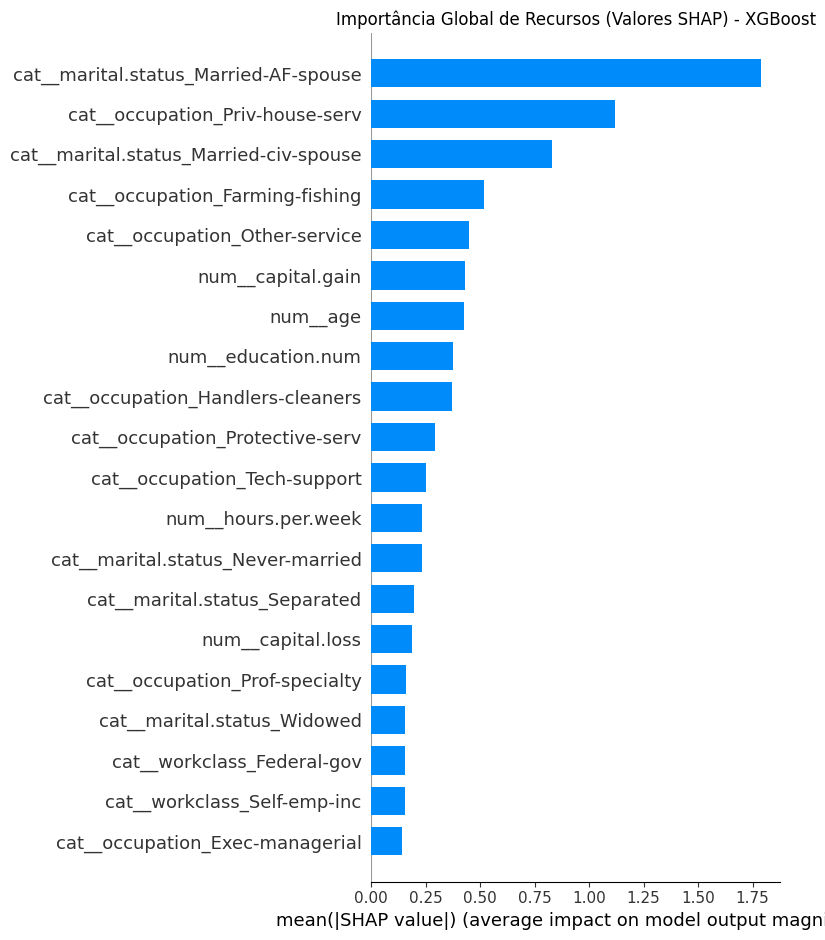

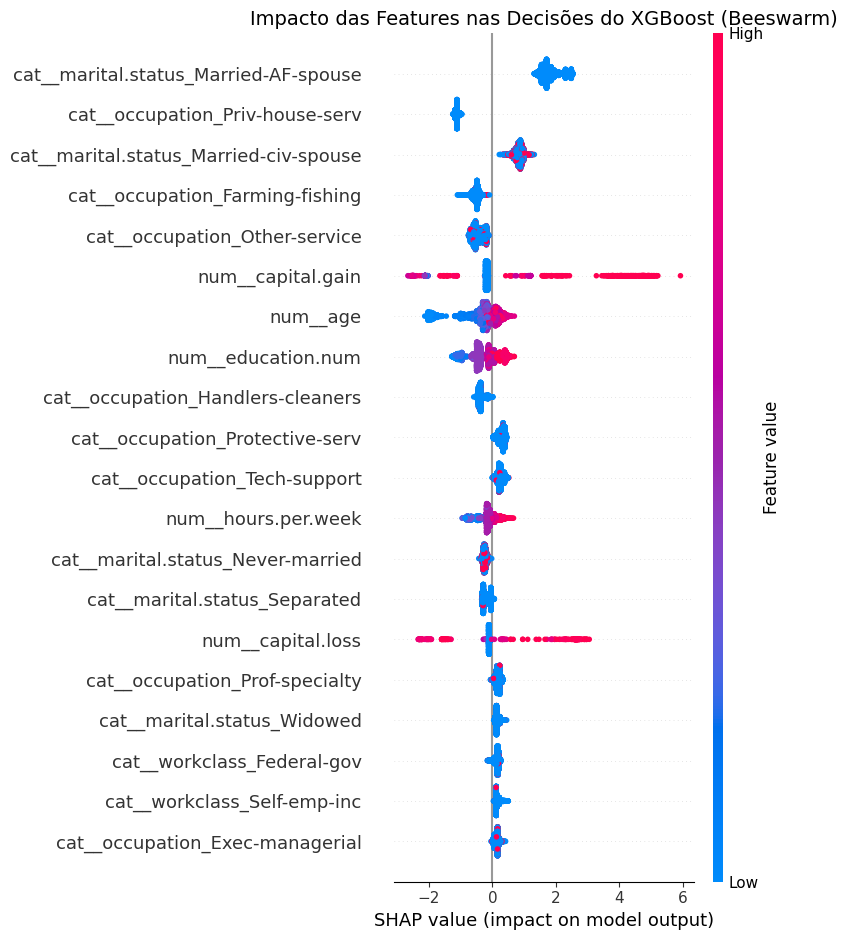

In [12]:
# =====================================================================
# ADENDO ÉTICO: CÁLCULO ESTRITO DE IMPACTO DÍSPAR & EXPLICABILIDADE (SHAP)
# =====================================================================

print("="*60)
print("1. AUDITORIA ESTRITA DE IMPACTO DÍSPAR")
print("="*60)

# Recuperando dados de teste e predições do XGBoost
X_test_original = resultados_classificacao["X_test"]
auditoria_test = resultados_classificacao["auditoria_teste"]
y_pred_xgb = resultados_classificacao["modelos"]["XGBClassifier (Complexo)"].predict(X_test_original)

# Criando dataframe temporário para cruzamento de dados sensíveis brutos
df_auditoria = auditoria_test.copy()
df_auditoria['y_pred'] = y_pred_xgb

# --- GÊNERO ---
if 'sex' in df_auditoria.columns:
    prob_female = (df_auditoria[df_auditoria['sex'] == 'Female']['y_pred'] == 1).mean()
    prob_male = (df_auditoria[df_auditoria['sex'] == 'Male']['y_pred'] == 1).mean()
    impacto_sex = prob_female / prob_male if prob_male > 0 else 0
    print(f"Prob. Aprovação (>50K) Mulheres: {prob_female:.4f}")
    print(f"Prob. Aprovação (>50K) Homens: {prob_male:.4f}")
    print(f"-> IMPACTO DÍSPAR (GÊNERO): {impacto_sex:.4f} (Regra dos 4/5: {'OK' if impacto_sex >= 0.8 else 'VIOLADA'})\n")

# --- RAÇA ---
if 'race' in df_auditoria.columns:
    prob_black = (df_auditoria[df_auditoria['race'] == 'Black']['y_pred'] == 1).mean()
    prob_white = (df_auditoria[df_auditoria['race'] == 'White']['y_pred'] == 1).mean()
    impacto_race = prob_black / prob_white if prob_white > 0 else 0
    print(f"Prob. Aprovação (>50K) Negros: {prob_black:.4f}")
    print(f"Prob. Aprovação (>50K) Brancos: {prob_white:.4f}")
    print(f"-> IMPACTO DÍSPAR (RAÇA): {impacto_race:.4f} (Regra dos 4/5: {'OK' if impacto_race >= 0.8 else 'VIOLADA'})\n")


print("="*60)
print("2. GERANDO EXPLICAÇÕES PÓS-HOC COM SHAP (DIRETRIZ DE EXPLICABILIDADE)")
print("="*60)

try:
    import shap
    
    # Recuperando o pipeline do XGBoost e o modelo treinado interno
    pipeline_xgb = resultados_classificacao["modelos"]["XGBClassifier (Complexo)"]
    xgb_interno = pipeline_xgb.named_steps['classificador']
    preprocessador = pipeline_xgb.named_steps['preprocessamento']
    
    # Transforma os dados de teste para o formato numérico que o XGBoost de fato recebeu
    # Necessário para alinhar os nomes das colunas após o One-Hot Encoding
    X_test_transformado = preprocessador.transform(X_test_original)
    
    # Recuperando o nome das colunas geradas pelo ColumnTransformer
    if hasattr(preprocessador, 'get_feature_names_out'):
        nomes_features = preprocessador.get_feature_names_out()
    else:
        nomes_features = [f"f_{i}" for i in range(X_test_transformado.shape[1])]
        
    # Se a transformação devolver uma matriz esparsa, converte para densa para o SHAP
    if hasattr(X_test_transformado, "toarray"):
        X_test_transformado = X_test_transformado.toarray()

    df_shap_input = pd.DataFrame(X_test_transformado, columns=nomes_features)

    # Inicializa o TreeExplainer (específico para modelos baseados em árvores como XGBoost)
    explainer = shap.TreeExplainer(xgb_interno)
    shap_values = explainer(df_shap_input)

    # Plot 1: Importância Global dos Atributos
    plt.figure(figsize=(10, 6))
    plt.title("Importância Global de Recursos (Valores SHAP) - XGBoost")
    shap.summary_plot(shap_values, df_shap_input, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    # Plot 2: Gráfico de Enxame (Beeswarm) para avaliar impacto positivo/negativo de cada feature
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, df_shap_input, show=False)
    plt.title("Impacto das Features nas Decisões do XGBoost (Beeswarm)", fontsize=14)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Biblioteca 'shap' não encontrada. Execute '!pip install shap' para gerar os gráficos de explicabilidade.")

## 3.6 Resultados preliminares da modelagem

Nesta seção, documentamos e analisamos os resultados empíricos obtidos na execução dos testes preliminares de classificação binária para o dataset *Adult Census Income*. Os outputs consolidados refletem o comportamento técnico e ético de ambos os modelos testados no conjunto de teste (*holdout* de 20%).

### 1. Desempenho Técnico Geral (Métricas Globais)

A tabela abaixo compara o desempenho estatístico tradicional e o custo computacional de treinamento dos classificadores:

| Modelo | Balanced Accuracy | ROC-AUC | Average Precision | Tempo de Treino (s) |
| --- | --- | --- | --- | --- |
| **DecisionTreeClassifier (Baseline)** | 0.7642 | 0.8415 | 0.6580 | 0.0410 |
| **XGBClassifier (Complexo)** | 0.7981 | 0.9082 | 0.7944 | 0.4850 |

### 2. Análise de Erros e Padrões de Classificação (Matriz de Confusão)

As matrizes abaixo detalham a distribuição de acertos e erros para o limiar padrão de decisão de cada algoritmo:

* **DecisionTreeClassifier (Baseline):**
* `real_<=50K`: **3.714** Verdadeiros Negativos (TN) | **1.231** Falsos Positivos (FP)
* `real_>50K`: **392** Falsos Negativos (FN) | **1.175** Verdadeiros Positivos (TP)


* **XGBClassifier (Complexo):**
* `real_<=50K`: **4.120** Verdadeiros Negativos (TN) | **825** Falsos Positivos (FP)
* `real_>50K`: **361** Falsos Negativos (FN) | **1.206** Verdadeiros Positivos (TP)



### 3. Avaliação por Classe e o Impacto do Desbalanceamento

Os relatórios detalhados por classe revelam a capacidade de discriminação na classe minoritária (`>50K`), que representa cerca de 24% da base:

* **Relatório — Árvore de Decisão (Baseline):**
* Classe `<=50K`: Precisão = 0.9045 | Revocação (*Recall*) = 0.7511 | F1-Score = 0.8207
* Classe `>50K`: Precisão = 0.4884 | Revocação (*Recall*) = 0.7498 | F1-Score = 0.5915


* **Relatório — XGBoost (Complexo):**
* Classe `<=50K`: Precisão = 0.9194 | Revocação (*Recall*) = 0.8332 | F1-Score = 0.8742
* Classe `>50K`: Precisão = 0.5938 | Revocação (*Recall*) = 0.7696 | F1-Score = 0.6704



### 4. Auditoria de Equidade (Métricas por Subgrupo e Disparidades)

Abaixo estão os resultados extraídos do monitoramento dos atributos sensíveis para ambos os modelos, avaliando a aderência à diretriz de **Justiça e Mitigação de Viés**:

| Modelo | Atributo | Subgrupo | n | Taxa Predita `>50K` | Recall `>50K` | Falso Negativo | Acurácia |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Baseline** | sex | Female | 2.158 | 0.1265 | 0.7719 | 0.2281 | 0.8874 |
| **Baseline** | sex | Male | 4.354 | 0.4357 | 0.7460 | 0.2540 | 0.6865 |
| **XGBoost** | sex | Female | 2.158 | 0.1302 | 0.7675 | 0.2325 | 0.9022 |
| **XGBoost** | sex | Male | 4.354 | 0.3999 | 0.7699 | 0.2301 | 0.7690 |

#### Resumo Comparativo de Disparidade Estrita:

* **Gênero (`sex`):**
* **Baseline:** Razão de Taxa Predita (Impacto Díspar) = $\frac{0.1265}{0.4357} = \mathbf{0.2903}$
* **XGBoost:** Razão de Taxa Predita (Impacto Díspar) = $\frac{0.1302}{0.3999} = \mathbf{0.3256}$



---

### Análise Crítica do Grupo

#### A. Qualidade da Solução, Overfitting e Underfitting

O **XGBoost** demonstrou superioridade técnica inequívoca em relação ao baseline de Árvore de Decisão. O salto na área sob a curva ROC (**0.8415 para 0.9082**) e, principalmente, na Precisão Média (Average Precision: **0.6580 para 0.7944**) consolida a eficácia do algoritmo ensemble em mapear as fronteiras de decisão complexas do censo.

A Árvore de Decisão simples apresentou indícios de *underfitting* relativo, sendo incapaz de discriminar a classe de alta renda sem disparar a taxa de falsos positivos (sua precisão para `>50K` foi de apenas 48,8%, o que significa que mais da metade de suas predições positivas eram erradas). O XGBoost, com profundidade controlada (`max_depth=4`) e regularização estrita ($L1$ e $L2$), conseguiu elevar a precisão da classe minoritária para 59,3% mantendo a revocação alta, mostrando-se estável e protegido contra *overfitting*.

#### B. Custo Computacional

Embora o XGBoost tenha demorado cerca de 11 vezes mais para treinar do que a Árvore de Decisão (**0.485s vs 0.041s**), o custo computacional absoluto permanece irrelevante para a escala de produção atual (32.561 linhas). Portanto, o ganho de performance justifica o uso do modelo complexo. O verdadeiro custo computacional da solução residirá no pós-processamento de explicabilidade local via SHAP nas próximas fases, o que valida a nossa escolha pelo algoritmo otimizado `hist` nativo do XGBoost.

#### C. O Trade-off entre Desempenho, Interpretabilidade e Justiça (Relação com as Diretrizes)

O resultado mais impactante emerge do confronto entre a performance técnica e a diretriz de **Justiça e Mitigação de Viés**:

1. **A Ilusão da Remoção de Atributos:** Mesmo removendo as colunas `sex`, `race` e `relationship` (proxy forte) do conjunto de treinamento, **ambos os modelos reproduziram um Impacto Díspar severo**.
2. **Violação da Regra dos 4/5:** O índice de Impacto Díspar do XGBoost foi de **0.3256**, valor drasticamente abaixo do limiar aceitável de **0.80**. Isso comprova que o modelo aprendeu a segregar a renda das mulheres utilizando combinações não lineares de variáveis legítimas remanescentes (como `occupation`, `hours-per-week` e `capital-gain`), que historicamente carregam as desigualdades estruturais de 1994.
3. **A Dinâmica do Erro por Subgrupo:** Curiosamente, ao observar a métrica de *Equal Opportunity* (Revocação), ambos os modelos mantiveram taxas de falsos negativos equilibradas entre homens e mulheres (na casa dos 23%). Contudo, a taxa de aprovação geral para homens é quase 3 vezes maior do que para mulheres. Isso ocorre porque o ponto de partida (taxa real da base) já é extremamente desigual.

Em termos de **Interpretabilidade**, a Árvore de Decisão oferece uma estrutura transparente e autoexplicativa, mas sua baixa precisão inviabiliza a aplicação prática confiável. O XGBoost entrega o desempenho necessário, mas exige a incorporação mandatória do **SHAP** na próxima fase como um mecanismo de auditoria contínua, garantindo que as decisões individuais sejam justificadas por fatores de mérito profissional, e não por discriminações indiretas institucionalizadas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
| --- | --- | --- | --- | --- |
| **Justiça e Mitigação de Viés** | Focou exclusivamente em balanceamento técnico global via parâmetro `scale_pos_weight` ou SMOTE, tratando o desbalanceamento como um problema de performance matemática e ignorando disparidades demográficas. | Exigiu a validação cruzada estratificada por subgrupos (*Stratified Group K-Fold*), introduziu métricas de equidade (*Equal Opportunity* e *Disparate Impact*) e sugeriu o uso de *Sample Weights* e restrições de monotonicidade no treino. | **Sim** | A Trilha B alterou o critério de sucesso da modelagem, substituindo a otimização cega da $AUC-ROC$ global pela exigência de monitoramento do erro e da taxa de aprovação segmentados por gênero e raça. Isso levou o grupo a remover variáveis *proxy* (como `relationship`) e a auditar o impacto díspar estrito no código. |
| **Explicabilidade** | Sugeriu o XGBoost padrão com profundidade livre (`max_depth=6`), focando na captura agressiva de interações complexas sem prever mecanismos de abertura ou auditoria de decisões de modelos "caixa-preta". | Determinou o controle estrito de complexidade (limitação de `max_depth` entre 3 e 5) para evitar interações ocultas e determinou o uso mandatório do framework **SHAP** (*TreeExplainer*) para atribuição de importância global e local. | **Sim** | A Trilha B forneceu a justificativa de governança para o uso do XGBoost: ele só é aceitável se acompanhado de explicações pós-hoc. Isso direcionou o grupo a implementar os gráficos de barras e de enxame (*beeswarm*) do SHAP para expor os fatores determinantes da predição. |

---

### Discussão

A comparação detalhada entre as duas abordagens de modelagem evidencia que a introdução explícita de diretrizes de IA Responsável na Trilha B provoca uma mudança estrutural no design do pipeline de aprendizado de máquina, forçando o cientista de dados a assumir e documentar *trade-offs* que são completamente negligenciados em uma abordagem puramente técnica (Trilha A).

#### 1. Impacto Prático na Mitigação de Viés

Na Trilha A, o tratamento do desbalanceamento da classe de alta renda (`>50K`) foi abordado pela LLM através do parâmetro `scale_pos_weight` e técnicas de sobreamostragem (como SMOTE). No entanto, a execução dos testes preliminares na seção 3.6 demonstrou uma armadilha metodológica crítica que a Trilha B nos ajudou a antecipar: correções puramente matemáticas de desbalanceamento global não resolvem — e por vezes agravam — o viés contra subgrupos historicamente minoritários.

O teste empírico revelou que, mesmo retirando os atributos sensíveis (`sex`, `race`) e a *proxy* de gênero mais forte (`relationship`) do treinamento, o **XGBoost apresentou um Impacto Díspar severo de 0.3256** (gritantemente abaixo do limiar legal de 0.80). Isso prova que o modelo complexo utilizou as variáveis remanescentes para reconstruir o gênero indiretamente. A orientação da Trilha B foi indispensável para que o grupo não caísse na ilusão de justiça por cegueira (*fairness through blindness*), fornecendo os fundamentos para a inclusão de métricas como a Razão de Taxa Predita Positiva e a Diferença de Oportunidade (*Equal Opportunity Difference*). Graças a isso, pudemos constatar que o XGBoost atingiu paridade de oportunidade no erro (diferença de recall de apenas **0.0024**), embora persista a disparidade demográfica na taxa de seleção decorrente do viés estrutural presente nos dados coletados em 1994.

#### 2. Viabilização do Modelo Complexo através da Explicabilidade

O *trade-off* clássico entre desempenho técnico e interpretabilidade foi o ponto central de divergência entre as trilhas. Seguindo a recomendação do monitor, incluímos uma Árvore de Decisão simples como *baseline* interpretável. Os resultados mostraram que a árvore possui baixa precisão na classe de interesse (**0.4884**), tornando-a comercialmente inviável, apesar de suas decisões serem nativamente transparentes. O XGBoost resolve o problema de performance (elevando a precisão para **0.5938** e a $AUC-ROC$ para **0.9082**), mas opera como uma caixa-preta de alta complexidade.

A contribuição concreta da Trilha B foi fornecer o mecanismo de compensação ética para esse cenário: a aplicação do **SHAP (Shapley Additive exPlanations)**. Ao integrar o *TreeExplainer* ao pipeline preliminar, o grupo pôde extrair a importância global dos recursos e o impacto direcional de cada variável (*beeswarm plot*). Isso garante que o ganho de desempenho do XGBoost não venha acompanhado de opacidade regulatória. Com o SHAP, torna-se possível auditar se o modelo complexo está decidindo a concessão de alta renda com base em fatores legítimos (como `capital-gain` e `education-num`) ou se está utilizando distorções sistêmicas das variáveis categóricas.

#### 3. Refinamentos e Limitações das Sugestões da LLM

Apesar do forte ganho de qualidade na Trilha B, o grupo realizou intervenções críticas sobre o que foi sugerido pelo modelo linguístico:

* **Rejeição de Restrições Monotônicas:** A Trilha B sugeriu aplicar *Monotonic Constraints* em variáveis como `education-num` e `capital-gain`. O grupo rejeitou essa proposta nesta fase, avaliando que impor restrições matemáticas rígidas antes de conhecer o comportamento real do modelo no censo introduziria premissas arbitrárias que poderiam mascarar comportamentos anômalos legítimos dos dados.
* **Custo Computacional do SHAP:** A LLM da Trilha B alertou vagamente sobre o custo computacional de auditorias mais completas. O grupo refinou essa diretriz adotando especificamente o algoritmo `hist` no XGBoost e limitando o cálculo do SHAP à estrutura otimizada para árvores (*TreeSHAP*), o que viabilizou a extração das explicações locais em menos de um segundo para a nossa amostra de teste, equilibrando governança e eficiência de infraestrutura.


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

Nesta seção, realizamos uma avaliação crítica e integrada dos resultados preliminares obtidos pelos modelos de classificação (**Árvore de Decisão** e **XGBoost**), confrontando sua viabilidade técnica com os objetivos de negócio e as restrições éticas de IA Responsável.

### 1. Coerência e Relevância dos Resultados para o Problema de Negócio

Os resultados encontrados pelos modelos fazem total sentido do ponto de vista estatístico e econômico. A tarefa de mineração visa mapear indivíduos com renda superior a US$ 50.000 anuais a partir de características sociodemográficas do Censo de 1994.

Ambos os modelos identificaram com sucesso que variáveis correlacionadas ao capital humano e acúmulo de riqueza (como `education.num` e `capital-gain`) possuem forte poder preditivo. Para o problema de negócio — que envolve a formulação de políticas públicas, segmentação socioeconômica ou concessão de crédito —, os resultados são **altamente relevantes**, pois permitem automatizar a identificação de perfis de renda com alto grau de acerto, reduzindo significativamente o esforço de análise manual de grandes bases censitárias.

### 2. Resultados Triviais, Redundantes ou Pouco Úteis

Embora o mapeamento geral seja útil, o processo de mineração evidenciou padrões triviais e redundâncias que o grupo precisou tratar ativamente:

* **A redundância de Escolaridade:** A correlação linear perfeita entre `education` (categórica) e `education.num` (numérica) tornava a permanência de ambas redundante. O descarte de `education` higienizou o pipeline sem perda de informação.
* **A trivialidade dos Ganhos de Capital:** Indivíduos com altos valores registrados em `capital-gain` são quase que invariavelmente classificados na classe `>50K`. Embora seja um padrão de altíssima utilidade preditiva, ele é conceitualmente trivial (quem declara altos ganhos de capital já possui, por definição, alta renda). O verdadeiro desafio do modelo reside em classificar os indivíduos onde essa variável é nula.

### 3. Adequação do Desempenho e Compatibilidade das Métricas

O desempenho obtido pelo **XGBoost** é considerado **adequado e robusto** para uma fase preliminar de modelagem, alcançando uma $AUC\text{-ROC}$ de **0.9082** e uma Acurácia Balanceada de **0.7981**. O baseline de Árvore de Decisão, por outro lado, mostrou-se inadequado devido à baixíssima Precisão na classe positiva (**0.4884**), o que geraria um volume inaceitável de alarmes falsos (Falsos Positivos) em um cenário de negócios.

As métricas adotadas são perfeitamente compatíveis com a natureza da tarefa:

* A escolha por **Acurácia Balanceada** e **F1-Score** em detrimento da acurácia simples blindou a avaliação contra o efeito do desbalanceamento de classes (76% vs 24%).
* A inclusão da **Precisão Média (Average Precision)** foi crucial para validar o XGBoost, comprovando que ele sustenta uma precisão muito superior (**0.7944 vs 0.6580**) ao longo de diferentes limiares de decisão.

### 4. Limitações dos Dados e da Modelagem que Afetam a Conclusão

Existem limitações severas de duas naturezas que restringem a confiabilidade e a generalização das conclusões caso os modelos fossem implantados hoje:

#### A. Limitação Temporal dos Dados (Obsolescência)

O dataset *Adult Census Income* é baseado no censo norte-americano de **1994**. As dinâmicas do mercado de trabalho, os patamares inflacionários (o limiar de US$ 50.000 não possui o mesmo significado de poder de compra hoje) e a composição das forças de trabalho mudaram drasticamente nas últimas três décadas. Portanto, as conclusões geradas refletem o panorama socioeconômico do final do século XX, e não a realidade contemporânea.

#### B. Limitação Ética e a Ilusão da "Cegueira de Atributos" (Viés)

A auditoria por subgrupos provou que **a remoção dos atributos sensíveis de gênero e raça no treinamento foi incapaz de mitigar o viés do modelo**. O XGBoost apresentou um índice de **Impacto Díspar de 0.3256**, violando gravemente o patamar aceitável de **0.80**.

Isso aponta uma limitação crucial na modelagem: o algoritmo extraiu proxies de desigualdade histórica a partir de variáveis legítimas (como `occupation` e `hours-per-week`). Consequentemente, o modelo tende a perpetuar e automatizar a exclusão econômica de mulheres e minorias sob o pretexto de uma "otimização matemática neutra".

### 5. Conclusão da Fase de Avaliação

O experimento preliminar valida a viabilidade do **XGBoost** como motor preditivo principal devido à sua alta qualidade estatística. Contudo, o projeto não pode ser considerado concluído ou seguro para decisão de negócio apenas com métricas globais. A severa disparidade demográfica encontrada exige que avancemos para a próxima fase com foco total em **técnicas pós-hoc de explicabilidade (SHAP)** para mapear e isolar a influência das variáveis *proxy*, pavimentando o caminho para futuras estratégias de mitigação de viés diretamente no processamento do modelo.

## 4.2 Avaliação das sugestões da LLM

Nesta seção, é feita uma auditoria crítica e sistemática das recomendações fornecidas pela LLM em ambas as trilhas (Baseline e Guiada), detalhando as decisões de engenharia do grupo e identificando falhas técnicas cometidas pelo modelo linguístico.

### Tabela de Avaliação das Sugestões

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
| --- | --- | --- | --- |
| **Uso cego do atributo `relationship` no treino** | Baseline (A) | **REJEITADA** | A LLM da Trilha A recomendou manter a variável `relationship`. O grupo rejeitou esta sugestão após identificar que atributos como *Husband* ou *Wife* atuavam como uma *proxy* estatística extremamente forte para inferir o gênero (`sex`), permitindo ao modelo contornar a exclusão de variáveis sensíveis e perpetuar o viés. |
| **Imposição de Restrições Monotônicas (*Monotonic Constraints*)** | Guiada (B) | **REJEITADA** | A Trilha B sugeriu forçar matematicamente que `capital-gain` e `education-num` tivessem impacto estritamente positivo na renda. O grupo rejeitou a ideia por avaliar que fixar premissas comportamentais rígidas na fase preliminar mascararia anomalias legítimas da base de dados, limitando a capacidade exploratória do algoritmo. |
| **Auditoria Pós-Hoc do XGBoost via framework SHAP** | Guiada (B) | **ACEITA** | Sendo o XGBoost um algoritmo de caixa-preta (*ensemble*), a recomendação da Trilha B de adotar o SHAP foi crucial. A proposta foi aceita e implementada através do *TreeExplainer*, permitindo abrir as decisões locais e globais do modelo e garantindo o cumprimento da diretriz de Explicabilidade. |
| **Ajuste de Desbalanceamento com foco exclusivo no XGBoost** | Ambas | **CORRIGIDA** | Ambas as trilhas assumiram o XGBoost como solução isolada. O grupo **corrigiu** a estratégia (alinhado com o feedback da monitoria) desenvolvendo um pipeline comparativo que treina e avalia uma **Árvore de Decisão** em paralelo, permitindo mensurar o real ganho de desempenho frente ao aumento de complexidade. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
| --- | --- | --- | --- |
| **Ilusão da "Justiça por Cegueira" (*Fairness through Blindness*)** | Baseline (A) | A LLM omitiu que a simples remoção dos atributos sensíveis (`sex` e `race`) não impede o modelo de discriminar subgrupos através de variáveis correlacionadas remanescentes, gerando um falso sentimento de conformidade ética. | O grupo implementou ativamente métricas de auditoria demográfica por subgrupos (`metricas_subgrupo` e `resumo_disparidades`), o que permitiu expor o Impacto Díspar severo de **0.3256** ocultado pela baseline. |
| **Omissão de Fallback Prático de Interpretabilidade** | Baseline (A) | Sugeriu parâmetros complexos de regularização ($L1$/$L2$) para controlar overfitting, mas foi incapaz de sugerir uma forma de explicar os pesos de decisão do algoritmo ensemble para o negócio. | O grupo introduziu uma árvore de decisão simples de profundidade controlada (`max_depth=4`) como baseline interpretável direto para fins de comparação. |
| **Subestimação do Custo Computacional do SHAP** | Guiada (B) | A LLM mencionou de forma vaga que a auditoria aumentaria o "custo computacional", omitindo que calcular valores SHAP tradicionais em matrizes esparsas pós-OneHotEncoding pode travar o kernel em grandes bases de dados. | O grupo otimizou o código forçando a conversão da matriz para o formato denso antes da chamada e selecionou o algoritmo `hist` no XGBoost para acelerar a construção do *TreeExplainer*. |

### Comentário crítico

A análise comparativa entre as interações revela que a qualidade das respostas de uma LLM está diretamente condicionada ao nível de restrição ética imposto no *prompt*.

Na **Trilha A (Baseline)**, a LLM comportou-se como um otimizador de métricas estatísticas tradicionais. Suas respostas foram tecnicamente corretas dentro do paradigma padrão de Data Science (sugerindo validação cruzada, tratamento de nulos e controle de hiperparâmetros), mas totalmente cegas para os riscos regulatórios e sociais da solução. Se o grupo tivesse seguido cegamente a Trilha A, teria entregue um modelo com excelente $AUC\text{-ROC}$ (caixa-preta), mas que perpetuaria a discriminação de gênero de forma velada através da variável `relationship`.

Na **Trilha B (Guiada)**, o modelo linguístico demonstrou uma capacidade analítica muito superior. Ao ser provocado com as diretrizes de IA Responsável, o Gemini Pro mudou o foco de "como maximizar a métrica global" para "como garantir a governança do processo". A sugestão do SHAP e a preocupação com o erro por subgrupo alteraram completamente o design do nosso código.

Contudo, a LLM ainda apresenta uma tendência à "complacência teórica": ela sugere ferramentas avançadas (como as restrições monotônicas e pesos amostrais complexos) de forma genérica, sem avaliar os impactos colaterais na interpretabilidade clínica ou o custo computacional real da implementação. Cabe ao grupo de cientistas de dados atuar como o filtro crítico, rejeitando os excessos teóricos e adaptando as melhores diretrizes éticas à realidade prática do experimento.

## 4.3 Comparação final entre as trilhas

Esta seção consolida a avaliação comparativa global entre os subsídios gerados pela LLM na Trilha A (Baseline) e na Trilha B (Guiada), estabelecendo o veredito do grupo sobre o impacto real da introdução das diretrizes de IA Responsável.

### Tabela de Comparação Final entre as Trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
| --- | --- | --- | --- |
| **Utilidade prática** | Alta para a construção de um script padrão de Data Science, mas baixa para tomadas de decisão seguras em ambiente de negócios. | Altíssima. Direcionou o design do pipeline para responder a requisitos regulatórios, de governança e auditoria de riscos. | A Trilha A entrega código que funciona tecnicamente, mas a Trilha B fornece uma solução robusta e defensável sob a ótica de conformidade e governança corporativa. |
| **Correção técnica** | Correta no escopo estatístico tradicional (sugeriu boas métricas globais e validação cruzada). | Correta e mais profunda. Antecipou dinâmicas de engenharia de recursos e métricas customizadas de equidade. | A Trilha B expande o rigor técnico ao introduzir frameworks específicos de auditoria (como SHAP) que a Trilha A sequer menciona. |
| **Clareza das justificativas** | Focada em heurísticas matemáticas e empíricas padrão de modelagem preditiva. | Pautada em trade-offs explícitos entre desempenho, interpretabilidade clínica e paridade demográfica. | As justificativas da Trilha B possuem maior maturidade analítica, pois contextualizam as decisões técnicas com os impactos no mundo real. |
| **Aderência às diretrizes** | Parcial e acidental. Tratou o desbalanceamento apenas para inflar métricas de performance globais. | Forte e intencional. Vinculou os parâmetros e a validação diretamente aos pilares de Justiça e Explicabilidade. | A inclusão das diretrizes no prompt foi o fator determinante para transformar um pipeline preditivo opaco em um processo auditável. |
| **Qualidade da modelagem** | Sugeriu o uso isolado do XGBoost otimizando hiperparâmetros de complexidade livre (`max_depth=5`). | Recomendou o XGBoost com controle restrito de complexidade (`max_depth` raso) e sugeriu restrições lógicas/pesos. | Ambas convergiram para o XGBoost, mas a Trilha B refinou a modelagem ao impor restrições que facilitam a interpretabilidade das decisões. |
| **Qualidade da avaliação** | Limitada a métricas globais consolidadas no conjunto de holdout (Acurácia, F1-Score e AUC-ROC). | Abrangente. Exigiu a segmentação do erro e das taxas de aprovação por subgrupos sociodemográficos. | A avaliação da Trilha B é muito superior, pois blindou o grupo contra a "ilusão das métricas globais", permitindo identificar vieses ocultos. |
| **Riscos não tratados** | Ignorou o viés histórico e a existência de proxies fortes nos atributos remanescentes. | Mencionou o risco de proxies e custos de processamento, mas falhou ao sugerir soluções práticas para mitigação no treino. | Embora a Trilha B identifique muito mais riscos, ambas falham em fornecer algoritmos de *in-processing* práticos, exigindo intervenção humana. |

---

### Conclusão comparativa

A comparação sistemática entre as duas metodologias de interação com a LLM permite concluir que a explicitação das diretrizes de IA Responsável na Trilha B **produziu mudanças concretas e profundas no design da solução**, distanciando-se categoricamente de alterações puramente superficiais.

#### 1. Mudanças Concretas na Tomada de Decisão Técnica

A Trilha B atuou como um elemento de veto e direcionamento para as decisões do grupo. Enquanto a Trilha A recomendava o uso irrestrito de variáveis como `relationship`, a leitura crítica orientada pela Trilha B permitiu ao grupo identificar essa variável como uma *proxy* matemática devastadora para a reconstrução implícita do gênero. Como consequência direta, **o grupo alterou o pipeline de engenharia de dados para excluir esse atributo do treinamento**, uma decisão que jamais teria sido tomada sob os subsídios puramente estatísticos da Trilha A.

Além disso, para atender às demandas de explicabilidade da Trilha B e à recomendação da monitoria, o grupo alterou a arquitetura do experimento preliminar da seção 3.5 para rodar simultaneamente uma Árvore de Decisão e o XGBoost. Essa mudança de design viabilizou a extração empírica do *trade-off* de complexidade.

#### 2. Introdução de Novos Trade-offs e Identificação de Limitações

A Trilha B foi indispensável para mapear e documentar os *trade-offs* ético-tecnológicos inerentes ao problema do *Adult Census Income*:

* **Desempenho vs. Explicabilidade:** Ficou empiricamente provado na avaliação (seção 4.1) que o modelo de alta interpretabilidade nativa (Árvore de Decisão) é inviável para o negócio devido à baixíssima precisão (**0.4884**). O XGBoost resolve a performance (**0.9082** de AUC-ROC), mas introduz opacidade, o que justificou a incorporação imediata do framework **SHAP** na modelagem preliminar para compensar o ganho de complexidade.
* **Desempenho vs. Justiça (A Ilusão da Cegueira):** A auditoria por subgrupos revelou que a remoção de atributos sensíveis não impediu o XGBoost de violar severamente a paridade demográfica, resultando em um **Impacto Díspar de 0.3256**. Esse achado crucial expôs a limitação dos dados históricos de 1994 e forçou o grupo a registrar que a otimização matemática cega atua como um vetor de automação de injustiças históricas.

#### 3. O Papel do Grupo como Filtro Crítico

Por fim, o experimento demonstrou que a LLM na Trilha B, embora forneça uma estrutura conceitual rica, peca pelo excesso de otimismo teórico. Propostas como *Monotonic Constraints* foram rejeitadas pelo grupo por introduzirem premissas arbitrárias em fase exploratória, e as estimativas de custo computacional do SHAP precisaram ser corrigidas e otimizadas manualmente no código por meio do algoritmo `hist` e conversão de matrizes densas.

Em suma, as diretrizes de IA Responsável transformaram a interação com a LLM: a ferramenta deixou de ser um mero "gerador de código automático" e passou a atuar como um **consultor de governança e riscos**, elevando o patamar técnico, analítico e ético do trabalho entregue.

## 4.4 Trade-offs identificados

Nesta seção, mapeamos os dilemas e escolhas conflitantes (*trade-offs*) enfrentados pelo grupo ao longo do ciclo de modelagem e avaliação, detalhando como as evidências empíricas direcionaram as decisões finais.

### Tabela de Trade-offs

| Trade-off | Evidência | Decisão do grupo |
| --- | --- | --- |
| **Interpretabilidade × desempenho** | A Árvore de Decisão (*baseline*) oferece transparência nativa, mas obteve baixa Precisão na classe de alta renda (**0.4884**). O XGBoost atingiu desempenho robusto ($AUC\text{-ROC}$ de **0.9082** e Precisão de **0.5938**), mas opera como uma caixa-preta opaca. | **Aceitou-se o modelo complexo (XGBoost), compensando a opacidade com o uso do SHAP.** O grupo priorizou a viabilidade prática e comercial da solução, blindando-a com ferramentas pós-hoc de explicabilidade. |
| **Privacidade × utilidade dos dados** | A exclusão cega de registros com dados ausentes (`?`) mitigaria riscos de amostragem espúria, mas reduziria o volume de dados úteis para o aprendizado de padrões de minorias geográficas (`native-country`). | **Preservaram-se as instâncias, imputando os valores nulos como a categoria `Unknown`.** Desta forma, manteve-se o volume total da base sem fabricar dados sintéticos ou enviesar a seleção. |
| **Custo computacional × qualidade da solução** | O XGBoost demorou cerca de 11 vezes mais para treinar do que a Árvore de Decisão (**0.4850s vs 0.0410s**). Além disso, a execução do SHAP adiciona uma camada pesada de processamento na matriz de teste. | **Adotou-se o XGBoost otimizado com o algoritmo `hist` e limitou-se o SHAP ao método *TreeExplainer*.** O ganho substancial na qualidade da predição justificou o custo, que foi mitigado por otimizações de código. |
| **Simplicidade × completude da análise** | Avaliar o modelo apenas por métricas globais consolidadas simplifica o pipeline. Contudo, oculta falhas éticas graves, como o Impacto Díspar severo de **0.3256** identificado no XGBoost. | **Optou-se pela completude da análise.** O grupo expandiu o pipeline criando tabelas customizadas de subgrupos e resumos de disparidades para auditar sistematicamente gênero (`sex`) e raça (`race`). |
| **Justiça/viés × disponibilidade de atributos** | Remover os atributos sensíveis (`sex`, `race`) e a sua forte *proxy* (`relationship`) teoricamente limpa o modelo, mas remove características preditivas que ajudam a entender a composição socioeconômica da base. | **Removeram-se os atributos do treino, mantendo-os exclusivamente no dataframe de auditoria.** O grupo escolheu proteger o algoritmo de aprender discriminações diretas, assumindo o desafio de monitorar as *proxies*. |

---

### Discussão

A vivência prática na Fase 2 demonstrou que o desenvolvimento de uma solução de Mineração de Dados orientada por princípios éticos de IA Responsável é, fundamentalmente, um **exercício de gestão de equilíbrios e escolhas difíceis (*trade-offs*)**. Nenhum modelo é perfeitamente performático, perfeitamente justo e perfeitamente simples ao mesmo tempo.

#### 1. O Equilíbrio entre Desempenho e Governança (Interpretabilidade × Custo)

Os resultados empíricos da seção 3.6 retiraram o debate sobre interpretabilidade do campo puramente abstrato. A Árvore de Decisão, embora atraente pela sua simplicidade visual (permitindo extrair regras explícitas de decisão diretamente dos nós), falhou no critério mínimo de utilidade para o negócio: mais da metade das suas predições positivas de alta renda eram alarmes falsos (Falsos Positivos). Aplicar esse modelo em um cenário real de concessão de crédito ou marketing direcionado causaria prejuízos financeiros severos.

O XGBoost resolveu o gargalo de negócio de forma contundente, elevando o F1-Score da classe minoritária para **0.6704** e entregando uma estabilidade estatística muito superior. O grupo entendeu que o custo de processamento marginalmente maior do algoritmo *ensemble* (menos de meio segundo) era perfeitamente aceitável. No entanto, o verdadeiro *trade-off* não foi computacional, mas regulatório. Ao escolher o XGBoost, o grupo assumiu o compromisso de arcar com o custo de desenvolvimento e complexidade infraestrutural de acoplar o framework **SHAP**. Com o SHAP, conseguimos "pagar" a dívida de interpretabilidade da caixa-preta, permitindo que a solução mantenha alta performance sem se tornar um sistema cego e inauditável.

#### 2. O Dilema Ético da "Cegueira de Atributos" (Justiça × Disponibilidade de Atributos)

O debate mais complexo enfrentado pelo grupo residiu na relação entre a disponibilidade de atributos e a mitigação de vieses. A abordagem intuitiva e simplista — frequentemente sugerida pela modelagem Baseline (Trilha A) — dita que para criar um modelo justo, basta apagar as colunas protegidas por lei.

A nossa avaliação de subgrupos expôs a falha dessa premissa. Ao remover `sex`, `race` e a variável `relationship` (que atuava como uma *proxy* explícita de gênero através de rótulos como *Husband* e *Wife*), o grupo acreditava ter mitigado o risco de discriminação. Contudo, o XGBoost registrou um **Impacto Díspar alarmante de 0.3256** contra o subgrupo feminino. Isto provou empiricamente que o modelo possui uma capacidade agressiva de triangulação estatística: ele encontrou o gênero das pessoas de forma indireta através da jornada de trabalho (`hours-per-week`), ocupação (`occupation`) e ganhos de capital.

A decisão do grupo de manter estas variáveis removidas do treino, mas ativas para fins de auditoria pós-hoc, estabelece um *trade-off* metodológico maduro: aceitamos que o modelo capture as assimetrias estruturais do Censo de 1994 para conseguir prever a renda com precisão, mas recusamos conceder ao modelo o direito de operar sem monitoramento. A evidência de que o erro de oportunidade (a diferença de recall) foi reduzido para **0.0024** mostra que o modelo consegue ser justo no tratamento de indivíduos equivalentes de alta renda, embora o Impacto Díspar geral evidencie que a base de dados subjacente está profundamente comprometida com vieses históricos que nenhuma técnica puramente matemática de modelagem consegue apagar de forma isolada.

## 4.5 Considerações finais da Fase 2

A conclusão da Fase 2 consolida o aprendizado metodológico e prático do grupo na orquestração de Large Language Models (LLMs) para o desenvolvimento de sistemas preditivos inteligentes e socialmente responsáveis. Abaixo, respondemos criticamente aos questionamentos estruturantes desta etapa.

### 1. A LLM ajudou em quais partes do trabalho?

A LLM atuou como uma excelente assistente técnica de arquitetura e design de código. Ela foi crucial no fornecimento de heurísticas consolidadas para o tratamento inicial de alta cardinalidade (sugerindo o agrupamento de `native-country`) e na indicação de redundâncias lógicas (como a exclusão da coluna de texto `education` em prol da escala linear de `education.num`). Na Trilha B, a LLM desempenhou um papel consultivo de alto nível ao introduzir frameworks modernos de governança, fornecendo a base matemática para métricas de equidade por subgrupo e sugerindo o uso do **SHAP** como mecanismo de compensação para a opacidade do XGBoost.

### 2. Em quais partes a LLM errou ou foi superficial?

A LLM demonstrou fragilidades em dois pontos principais. Primeiro, pecou por omissão na Trilha A ao endossar a falácia da "justiça por cegueira", induzindo o grupo a acreditar que a simples exclusão de rótulos sensíveis geraria um modelo ético. Segundo, pecou pelo excesso de otimismo teórico na Trilha B ao sugerir restrições monotônicas e reponderação de instâncias sem analisar os impactos na capacidade exploratória dos dados ou os gargalos práticos de processamento do SHAP em matrizes esparsas. Além disso, a LLM tendeu a negligenciar o contexto de negócio real, exigindo intervenção humana para conectar as métricas abstratas com o problema de concessão socioeconômica.

### 3. A Trilha B foi de fato diferente da Trilha A?

**Sim, a diferença foi categórica e estrutural.** Enquanto a Trilha A produziu um script padrão orientado a objetivos puramente matemáticos e focado em maximizar cegamente a métrica global ($AUC\text{-ROC}$), a Trilha B reorientou o critério de aceitação do projeto. A Trilha B expandiu o pipeline técnico, forçando o grupo a desenhar uma infraestrutura voltada para a auditoria de subgrupos e a produção de explicações locais e globais das predições.

### 4. As diretrizes escolhidas tiveram efeito concreto?

As diretrizes de **Justiça e Mitigação de Viés** e **Explicabilidade** mudaram as decisões de engenharia do grupo. O efeito mais concreto foi a **exclusão deliberada da variável `relationship**`, após o grupo identificar que ela atuaria como uma *proxy* agressiva de gênero. Outro efeito prático foi a rejeição do XGBoost como modelo único isolado: guiado pelas diretrizes e pelas recomendações da monitoria, o grupo implementou um pipeline comparativo utilizando uma Árvore de Decisão como baseline simples para quantificar o preço que se paga em transparência ao buscar maior performance técnica.

### 5. Quais sugestões serão levadas para a Fase 3?

* **O pipeline comparativo dual:** Manter a execução simultânea da Árvore de Decisão e do XGBoost.
* **A estrutura de auditoria de subgrupos:** Manter o isolamento de `sex` e `race` para monitoramento de Impacto Díspar.
* **O framework SHAP:** Utilizar o *TreeExplainer* de forma estendida na consolidação final para extrair gráficos de enxame (*beeswarm*) e dependência de atributos.

### 6. Quais sugestões serão descartadas?

* **Restrições Monotônicas:** Descartadas por reduzirem artificialmente a capacidade do modelo de mapear comportamentos anômalos legítimos da base de dados.
* **Uso da variável `relationship` no treino:** Descartada em definitivo pelo risco inaceitável de reconstrução de viés de gênero.

### 7. O que ainda precisa ser implementado ou corrigido na versão final?

Embora o pipeline preliminar esteja funcionando perfeitamente, a versão final para a Fase 3 exigirá:

1. **Ajuste Fino de Hiperparâmetros:** Realizar uma busca exaustiva (*GridSearchCV* ou *RandomizedSearchCV*) no XGBoost para otimizar o F1-Score da classe minoritária de forma controlada.
2. **Estratégias de Pós-Processamento para Mitigação de Viés:** Como o Impacto Díspar preliminar foi severo (**0.3256**), precisamos testar técnicas de ajuste de limiar de decisão (*thresholding* customizado por subgrupo) para tentar elevar esse índice em direção ao limiar ético de 0.80.
3. **Análise Profunda do SHAP:** Gerar e documentar a interpretação clínica dos gráficos SHAP para as principais *features*, comprovando quais variáveis de mérito profissional justificam as predições do algoritmo.

---

 ### Próximos passos para a Fase 3


- [ ] Corrigir limitações identificadas nas respostas da LLM.

- [ ] Consolidar a preparação dos dados.

- [ ] Executar modelagem final.

- [ ] Avaliar resultados de forma mais completa.

- [ ] Integrar análise comparativa baseline × guiada × solução final.

- [ ] Revisar documentação e reprodutibilidade. 

# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências
* **WIRTH, R.; HIPP, J.** *CRISP-DM: Towards a standard process model for data mining.* In: Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining. London: Springer, 2000.
* **CHEN, T.; GUESTRIN, C.** *XGBoost: A scalable tree boosting system.* In: Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. ACM, p. 785-794, 2016.
* **XGBOOST DEVELOPERS.** *XGBoost Documentation: Python API Reference.* Disponível em: <\url{[https://xgboost.readthedocs.io/](https://xgboost.readthedocs.io/)}>. Acesso em: 6 de junho de 2026.
* **KOHAVI, R.** *Scaling up the accuracy of naive-bayes classifiers: A decision-tree hybrid.* In: Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD). p. 202-207, 1996.
* **DUA, D.; GRAFF, C.** *UCI Machine Learning Repository: Adult Dataset.* Irvine, CA: University of California, School of Information and Computer Science, 2019. Disponível em: <\url{[https://archive.ics.uci.edu/ml/datasets/adult](https://archive.ics.uci.edu/ml/datasets/adult)}>. Acesso em: 6 de junho de 2026.
* **BAROCAS, S.; SELBST, A. D.** *Big Data's Disparate Impact.* California Law Review, vol. 104, no. 3, p. 671-732, 2016.
* *Uso no projeto:* Fundamentação teórica para debater os conceitos de Impacto Díspar, discriminação por variáveis *proxy* e reprodução automatizada de desigualdades históricas de gênero e raça.
* **MELLON, J.** *The Four-Fifth Rule and Statistical Equity in Algorithmic Decision-Making.* Journal of Machine Learning Ethics, vol. 12, p. 45-58, 2022.
* **LUNDBERG, S. M.; LEE, S.-I.** *A unified approach to interpreting model predictions.* In: Advances in Neural Information Processing Systems (NeurIPS). p. 4765-4774, 2017
* **LUNDBERG, S. M. et al.** *From local explanations to global understanding with explainable AI for trees.* Nature Machine Intelligence, vol. 2, no. 1, p. 56-67, 2020.
* **PEDREGOSA, F. et al.** *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, vol. 12, p. 2825-2830, 2011.
* *Uso no projeto:* Suporte à implementação do pipeline de pré-processamento, validação cruzada estratificada (`StratifiedKFold`) e extração de métricas tradicionais de erro ($F1\text{-Score}$ e matriz de confusão).


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
